## Model and Feature Enhancement
### Yilin Luo

## 1. Introduction

In today’s competitive financial services environment, accurately predicting the risk of loan default is essential for safeguarding profitability and reducing exposure to credit losses. In this project, we work with a real-world dataset containing a wide range of demographic, behavioral, and financial attributes of loan applicants to build a predictive model for default risk. Through meticulous data preparation, targeted feature enhancement for both categorical and numerical variables, and the application of automated machine learning (AutoML) techniques, we aim to maximize the model’s ability to identify high-risk borrowers. Our analysis not only compares the performance of multiple algorithms but also evaluates the business impact through lift curve analysis and profit-and-loss simulations, delivering practical recommendations that link predictive modeling directly to profitability and risk management in lending decisions.

## 2. Data Preparation and Report

In [1]:
#!pip install scikit-learn pandas numpy matplotlib seaborn plotly pycaret category_encoders h2o sweetviz

In [2]:
# data
import pandas as pd
import numpy as np

# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#import missingno as msno
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
#from wordcloud import WordCloud

from sklearn import datasets
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# styling
%matplotlib inline
sns.set_style('darkgrid')
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'

import os 
#from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

### Load Data

In [3]:
path = '/Users/yilin/Downloads'
data =  pd.read_csv(path + "/XYZloan_default_llm.csv")

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  16000 non-null  int64  
 1   Unnamed: 0    16000 non-null  int64  
 2   AP001         16000 non-null  int64  
 3   AP002         16000 non-null  int64  
 4   AP003         16000 non-null  int64  
 5   AP006         16000 non-null  object 
 6   AP007         16000 non-null  int64  
 7   AP008         16000 non-null  int64  
 8   CR004         16000 non-null  int64  
 9   CR009         16000 non-null  int64  
 10  CR015         16000 non-null  int64  
 11  CR017         16000 non-null  int64  
 12  CR018         16000 non-null  int64  
 13  CR019         16000 non-null  int64  
 14  MB005         15441 non-null  float64
 15  MB007         16000 non-null  object 
 16  PA022         15918 non-null  float64
 17  PA023         15918 non-null  float64
 18  PA028         15918 non-nu

In [5]:
# assign new column name using variables dictionary
columns = {
    'AP001': 'YR_AGE',
    'AP002': 'CODE_GENDER',
    'AP003': 'CODE_EDUCATION',
    'AP006': 'OS_TYPE',
    'AP007': 'LEVEL_APPL_CITY',
    'AP008': 'FLAG_IP_CITY_NOT_APPL_CITY',
    'CR004': 'CNT_QUERY_TIME_LAST_1MON',
    'CR009': 'AMT_LOAN_TOTAL',
    'CR015': 'MONTH_CREDIT_CARD_MOB_MAX',
    'CR017': 'SCORE_DEBIT_CARD_TOTAL_AMT',
    'CR018': 'SCORE_DEBIT_CARD_UTILITY_AMT',
    'CR019': 'SCORE_SINGLE_DEBIT_CARD_LIMIT',
    'MB005': 'YR_PHONE_ACTIVE',
    'MB007': 'Application_Device',
    'PA022': 'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL',
    'PA023': 'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL',
    'PA028': 'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS',
    'PA029': 'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS',
    'PA031': 'AVG_LEN_COLLECTION_CALLS',
    'TD001': 'TD_CNT_QUERY_LAST_7Day_P2P',
    'TD002': 'TD_CNT_QUERY_LAST_7Day_SMALL_LOAN',
    'TD003': 'TD_CNT_QUERY_LAST_7Day_BANK',
    'TD004': 'TD_CNT_QUERY_LAST_7Day_OTHER',
    'TD005': 'TD_CNT_QUERY_LAST_1MON_P2P',
    'TD006': 'TD_CNT_QUERY_LAST_1MON_SMALL_LOAN',
    'TD007': 'TD_CNT_QUERY_LAST_1MON_BANK',
    'TD008': 'TD_CNT_QUERY_LAST_1MON_OTHER',
    'TD009': 'TD_CNT_QUERY_LAST_3MON_P2P',
    'TD010': 'TD_CNT_QUERY_LAST_3MON_SMALL_LOAN',
    'TD011': 'TD_CNT_QUERY_LAST_3MON_BANK',
    'TD012': 'TD_CNT_QUERY_LAST_3MON_OTHER',
    'TD013': 'TD_CNT_QUERY_LAST_6MON_P2P',
    'TD014': 'TD_CNT_QUERY_LAST_6MON_SMALL_LOAN',
    'TD015': 'TD_CNT_QUERY_LAST_6MON_BANK',
    'TD016': 'TD_CNT_QUERY_LAST_6MON_OTHER',
    'TD022': 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN',
    'TD024': 'TD_CNT_QUERY_LAST_24MON_OTHER',
    'loan_default': 'Loan_Default',
    
}

# apply to your DataFrame
data = data.rename(columns=columns)

In [6]:
# drop three unused columns
data = data.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'reason'])

In [7]:
# updated data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 29 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   YR_AGE                                               16000 non-null  int64  
 1   CODE_GENDER                                          16000 non-null  int64  
 2   CODE_EDUCATION                                       16000 non-null  int64  
 3   OS_TYPE                                              16000 non-null  object 
 4   LEVEL_APPL_CITY                                      16000 non-null  int64  
 5   FLAG_IP_CITY_NOT_APPL_CITY                           16000 non-null  int64  
 6   CNT_QUERY_TIME_LAST_1MON                             16000 non-null  int64  
 7   AMT_LOAN_TOTAL                                       16000 non-null  int64  
 8   MONTH_CREDIT_CARD_MOB_MAX                            16000 non-nul

In [8]:
# Identify all object-dtype columns as categorical
cat_var = data.select_dtypes(include=['object']).columns.tolist()

# Identify all numeric columns (int64 & float64) as numeric
num_var = data.select_dtypes(include=['number']).columns.tolist()

# Remove the target from num_var (if it’s numeric)
target = 'Loan_Default'
if target in num_var:
    num_var.remove(target)

# Combine
X_vars = cat_var + num_var

In [9]:
# Verify
print("Categorical variables:", cat_var)

Categorical variables: ['OS_TYPE', 'Application_Device']


In [10]:
print("Numeric variables:", num_var)

Numeric variables: ['YR_AGE', 'CODE_GENDER', 'CODE_EDUCATION', 'LEVEL_APPL_CITY', 'FLAG_IP_CITY_NOT_APPL_CITY', 'CNT_QUERY_TIME_LAST_1MON', 'AMT_LOAN_TOTAL', 'MONTH_CREDIT_CARD_MOB_MAX', 'SCORE_DEBIT_CARD_TOTAL_AMT', 'SCORE_DEBIT_CARD_UTILITY_AMT', 'SCORE_SINGLE_DEBIT_CARD_LIMIT', 'YR_PHONE_ACTIVE', 'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL', 'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL', 'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS', 'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS', 'AVG_LEN_COLLECTION_CALLS', 'TD_CNT_QUERY_LAST_7Day_P2P', 'TD_CNT_QUERY_LAST_1MON_P2P', 'TD_CNT_QUERY_LAST_1MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_3MON_P2P', 'TD_CNT_QUERY_LAST_3MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_6MON_P2P', 'TD_CNT_QUERY_LAST_6MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_24MON_OTHER']


In [11]:
print("Target:", target)

Target: Loan_Default


In [12]:
data[target].value_counts()

Loan_Default
0    12924
1     3076
Name: count, dtype: int64

### Data Preparation

In [13]:
# split the data
X = data.drop(target, axis=1)
y = data[target]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
train, test= train_test_split(data, random_state=0)
[X_train.shape,X_test.shape, y_train.shape, y_test.shape]

[(12000, 28), (4000, 28), (12000,), (4000,)]

In [14]:
import sweetviz as sv

my_report = sv.analyze(train)
my_report.show_html() 

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


                                             |          | [  0%]   00:00 -> (? left)

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.



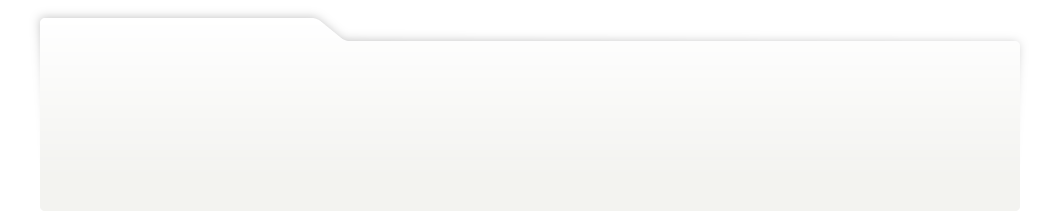
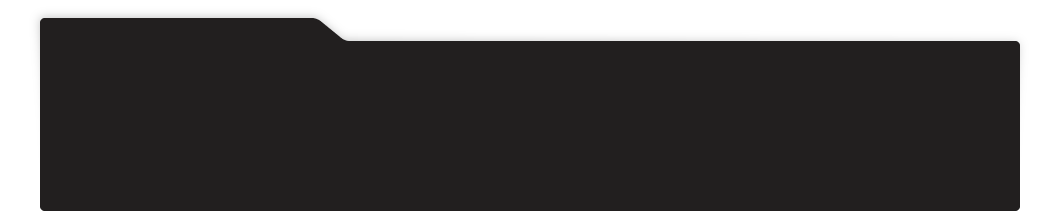
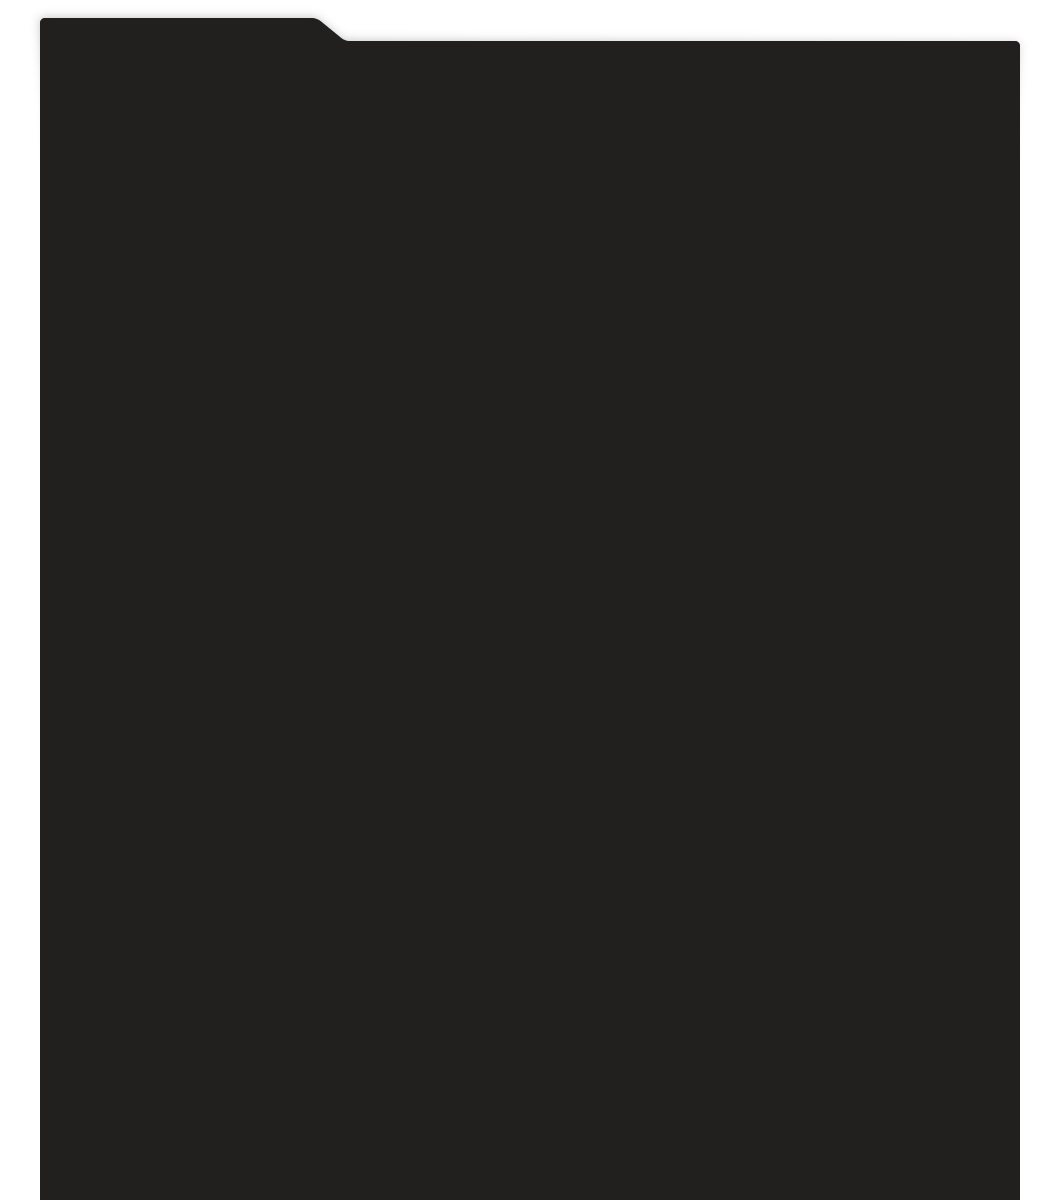
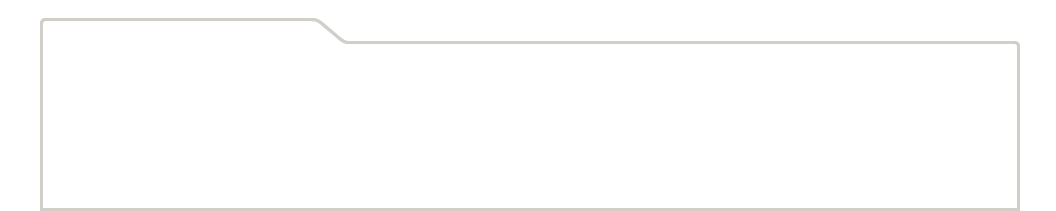
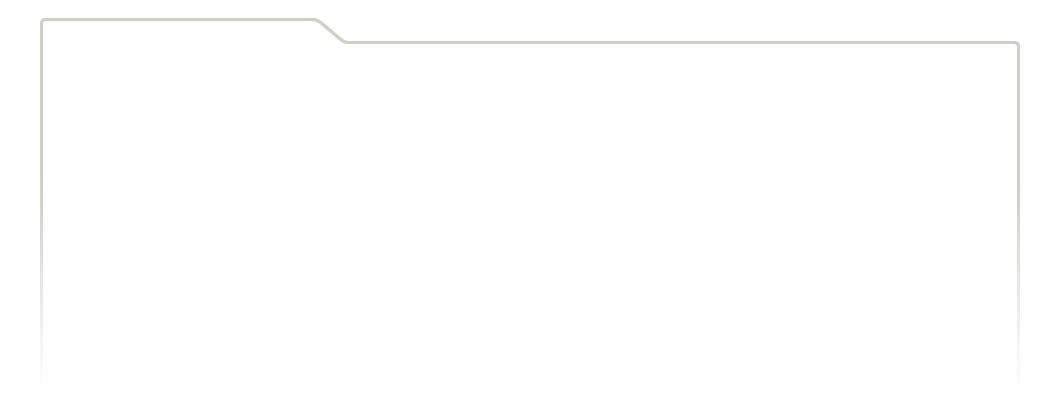
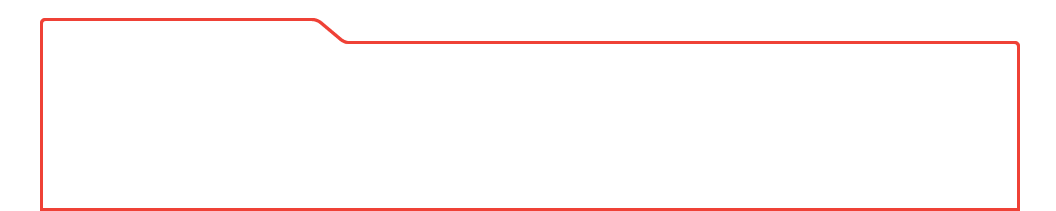
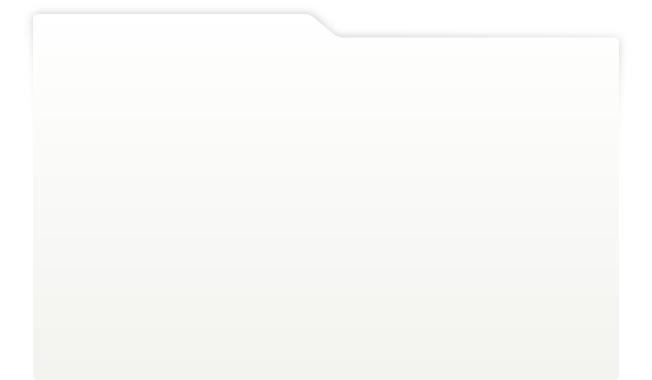
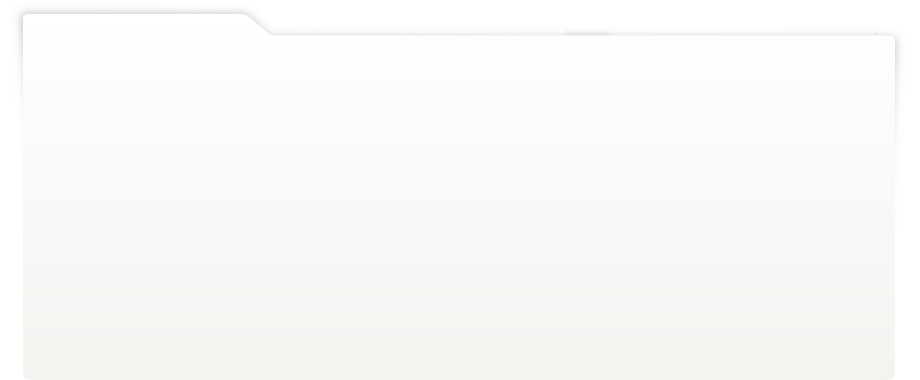
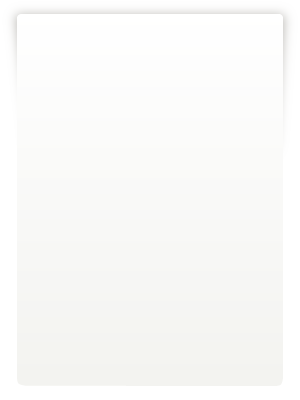
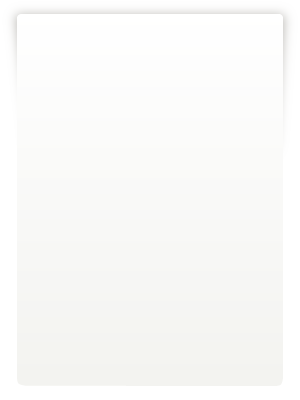
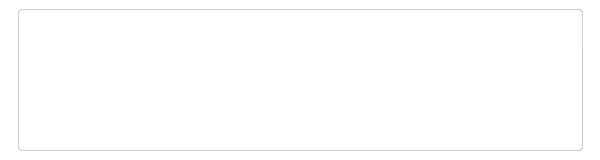
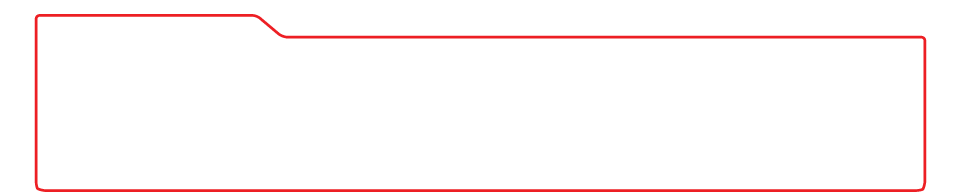
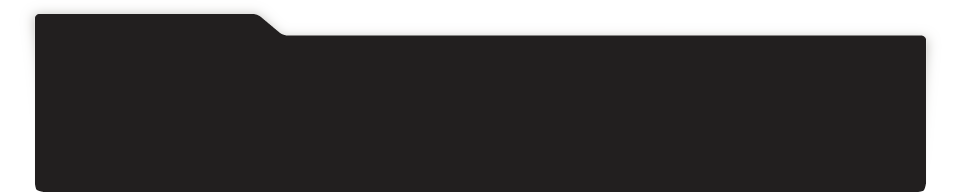
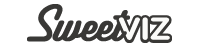
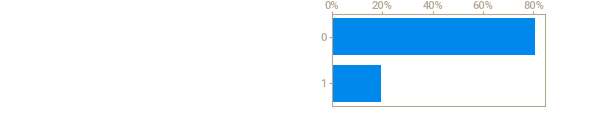
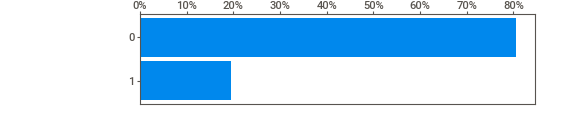
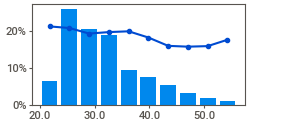
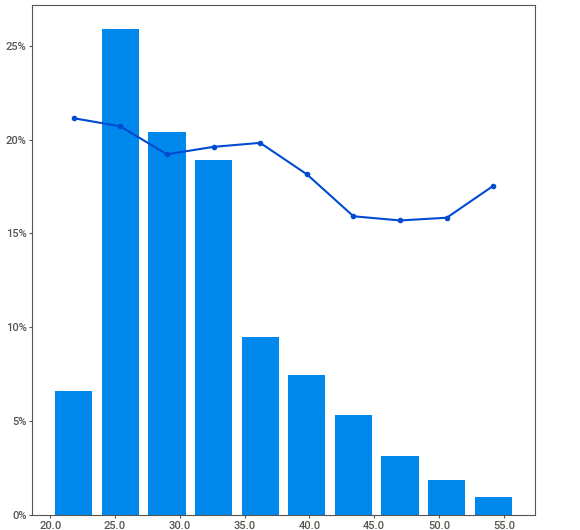
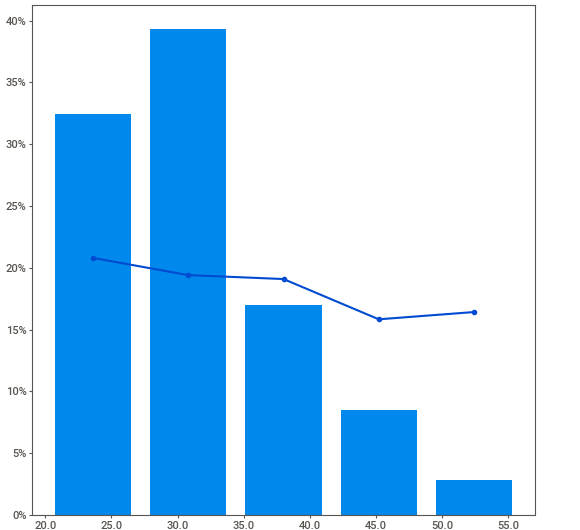
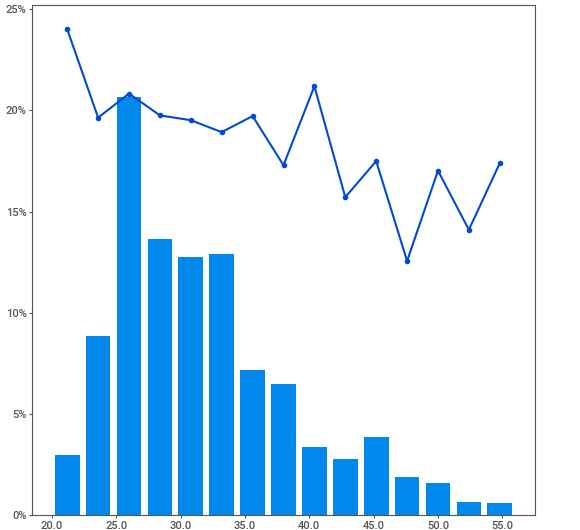
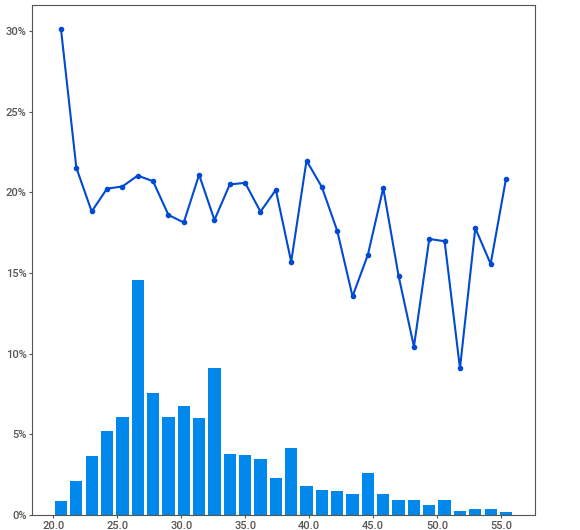
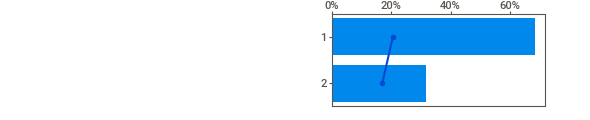
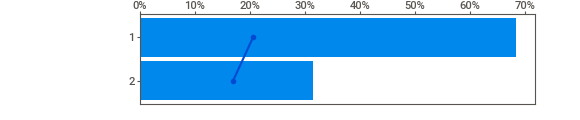
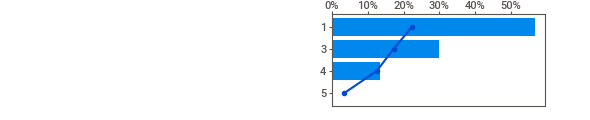
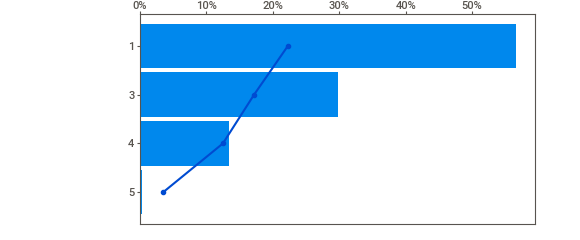
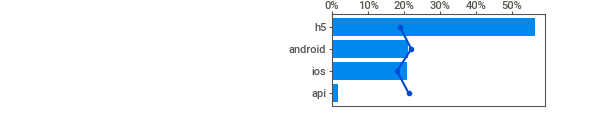
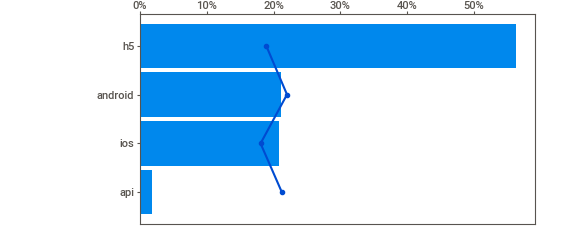
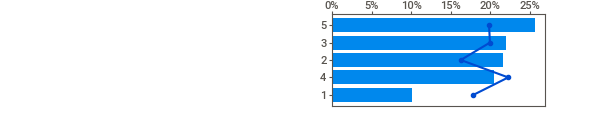
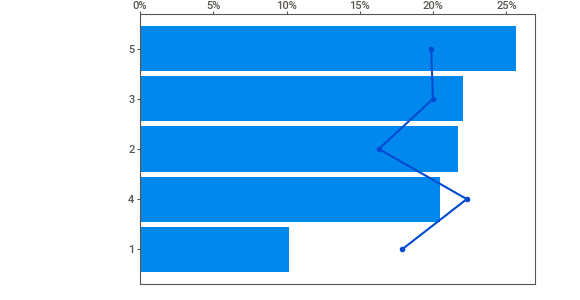
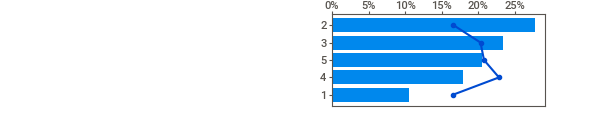
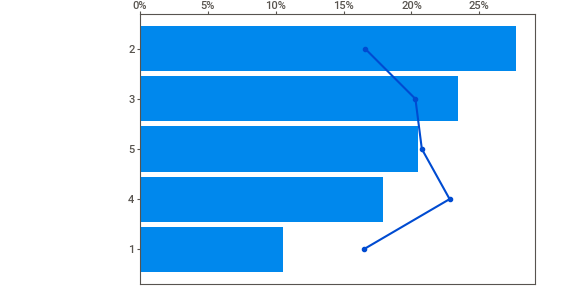
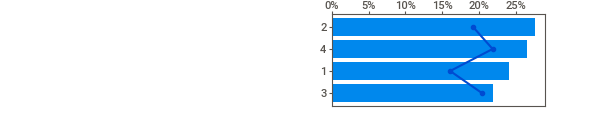
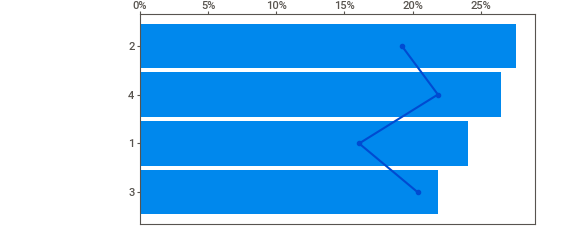
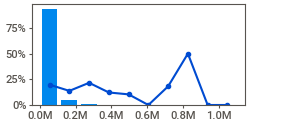
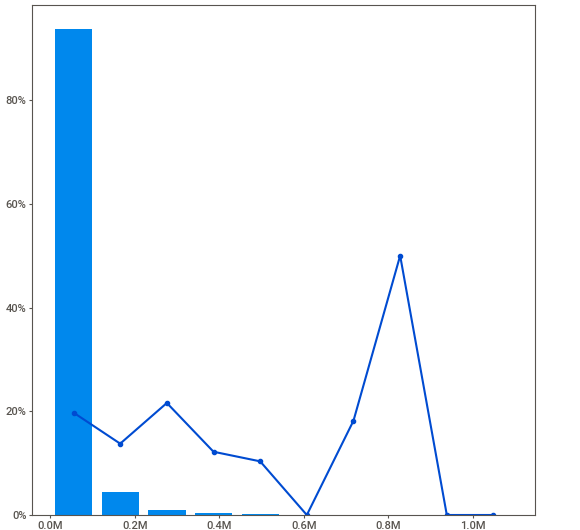
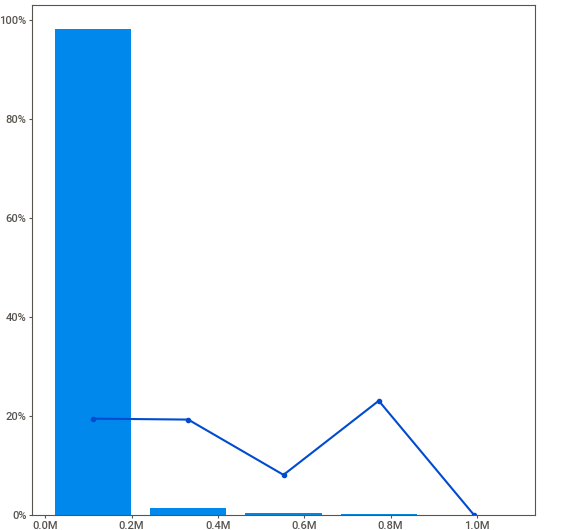
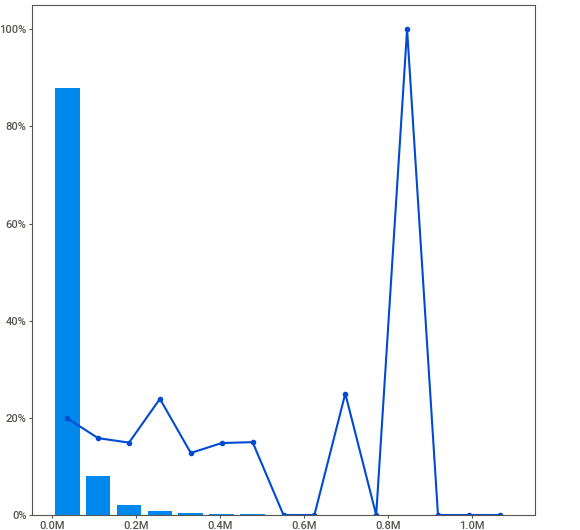
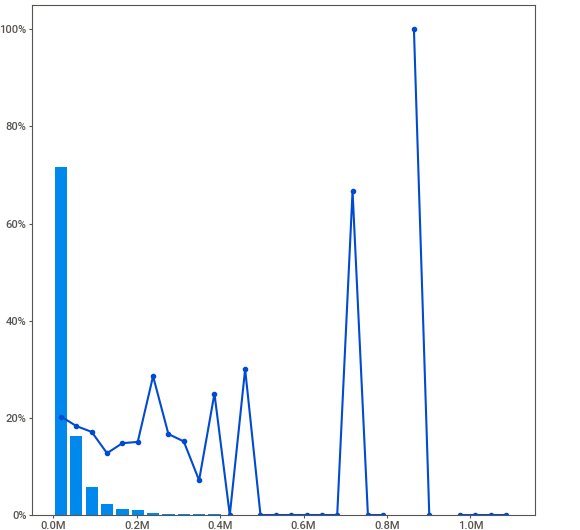
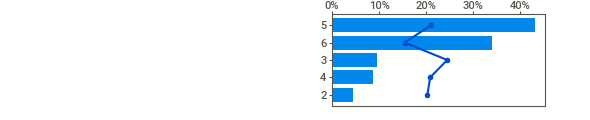
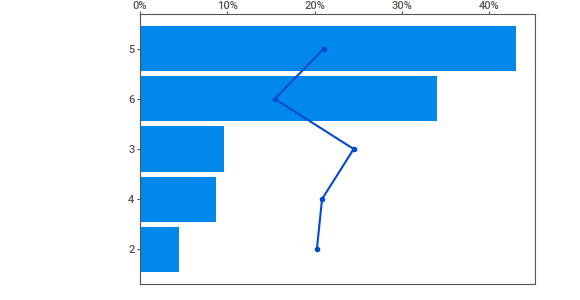
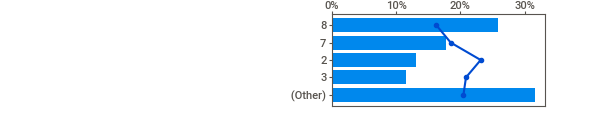
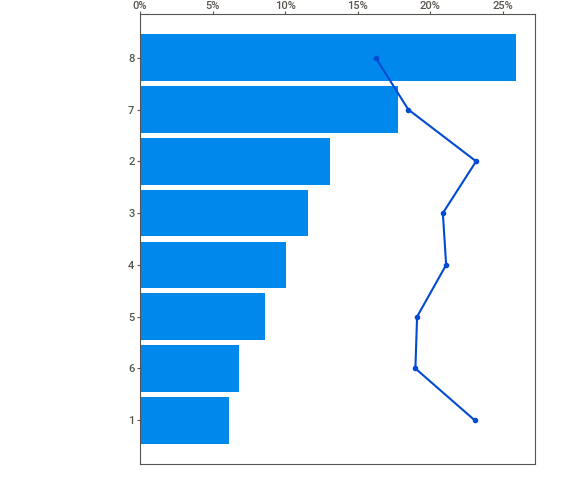
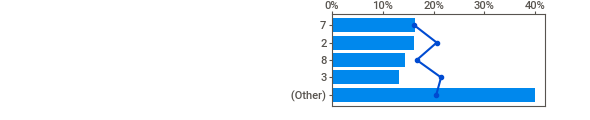
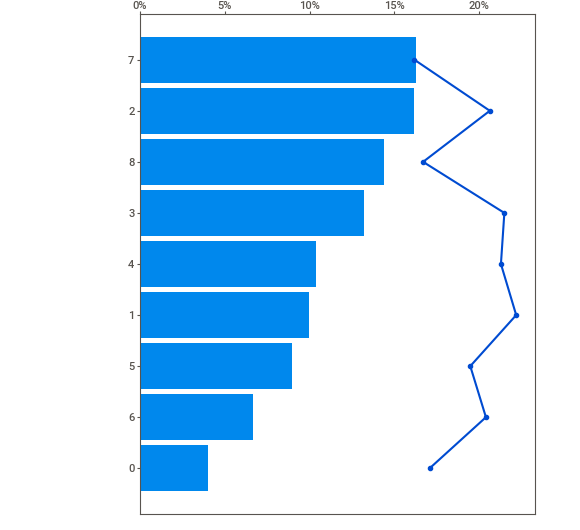
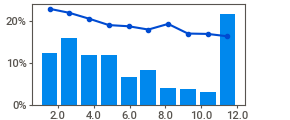
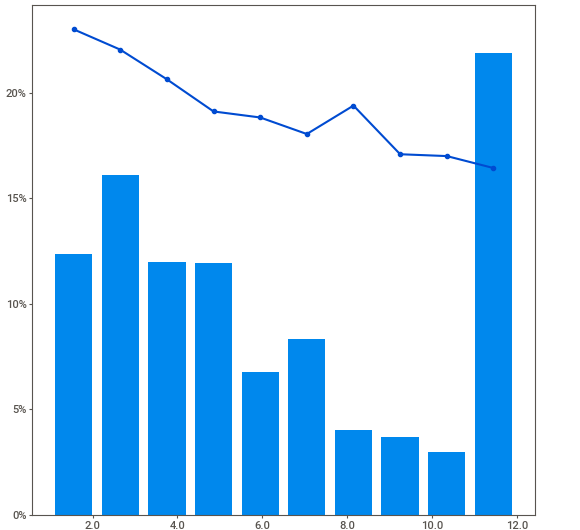
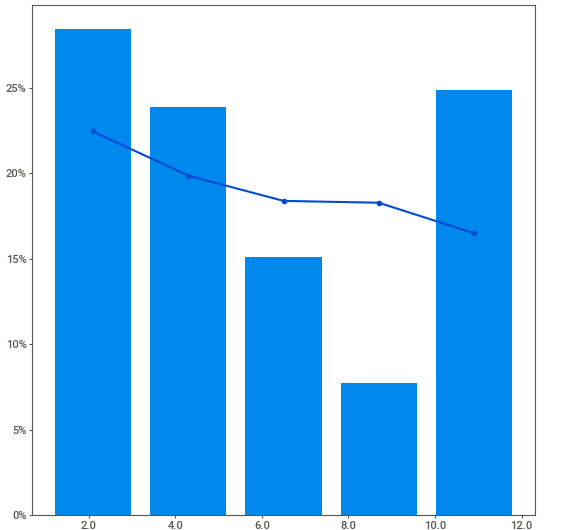
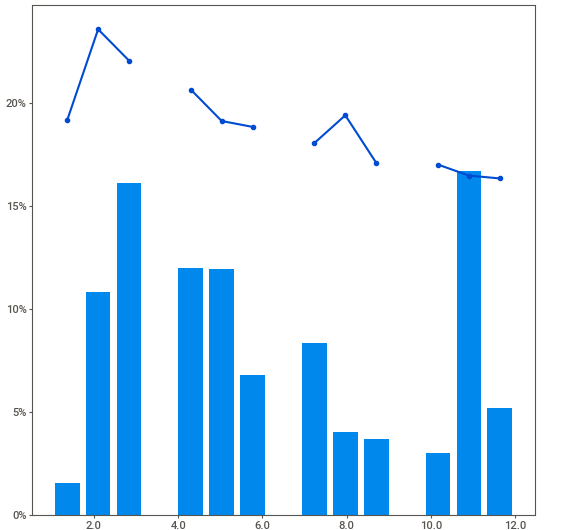
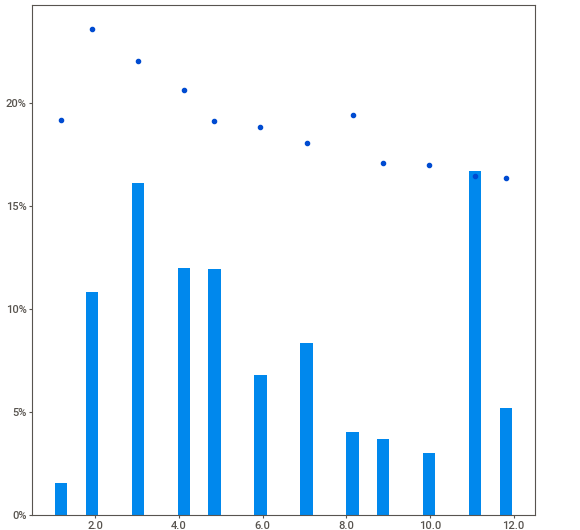
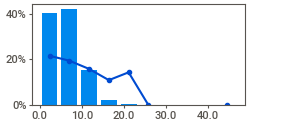
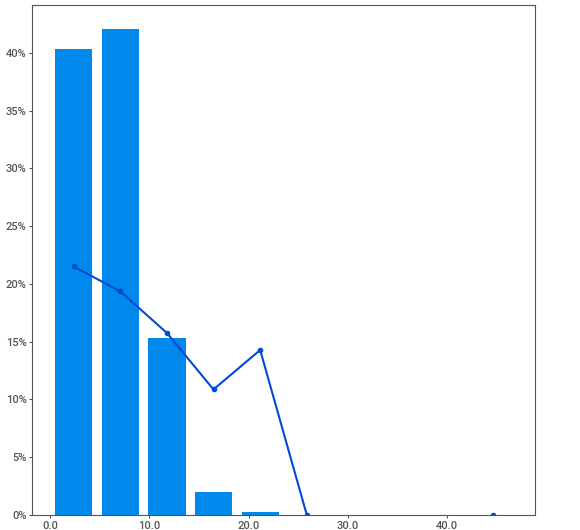
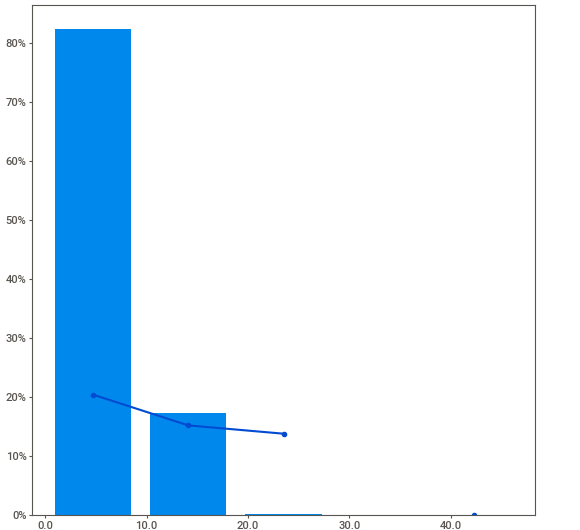
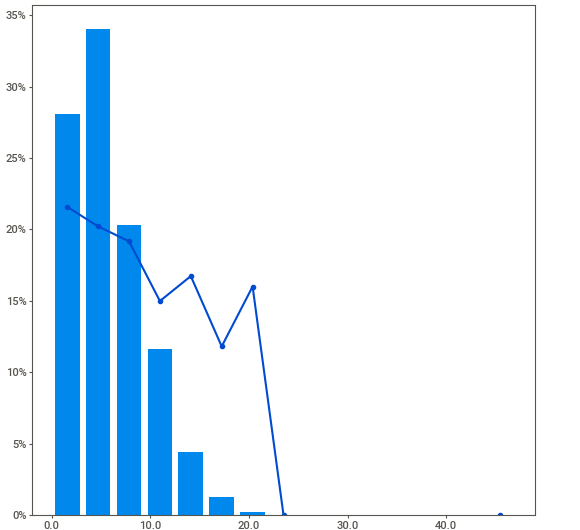
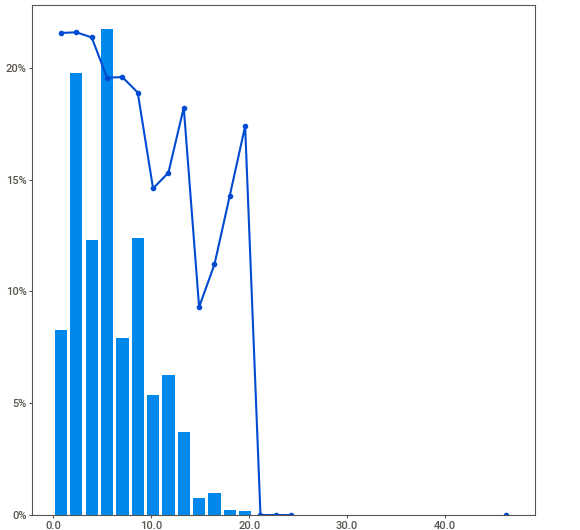
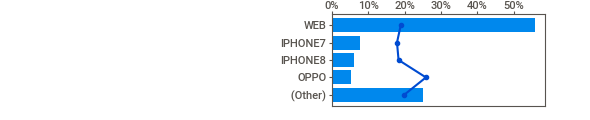
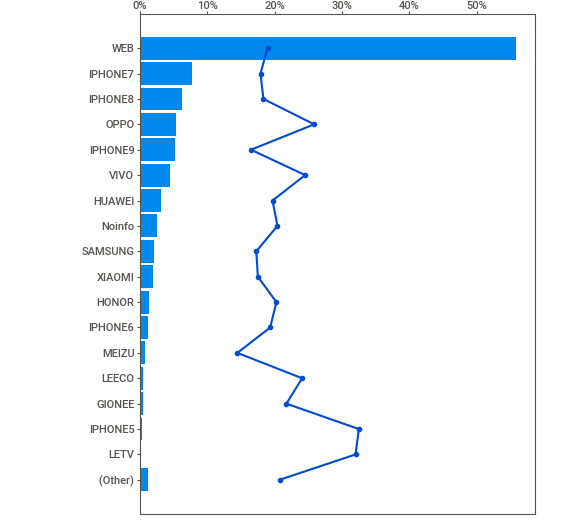
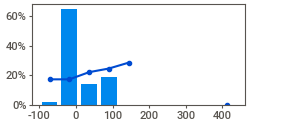
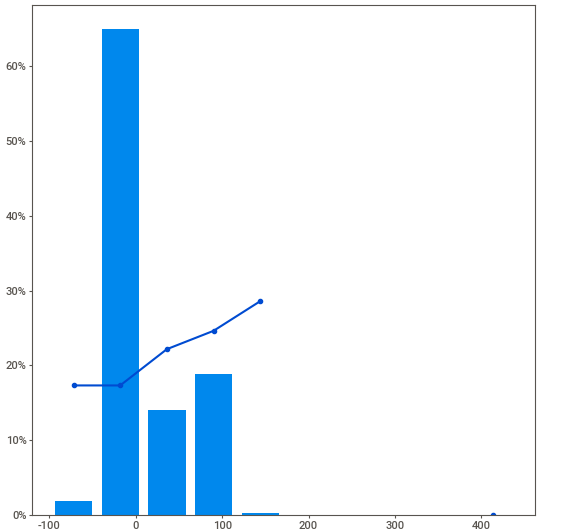
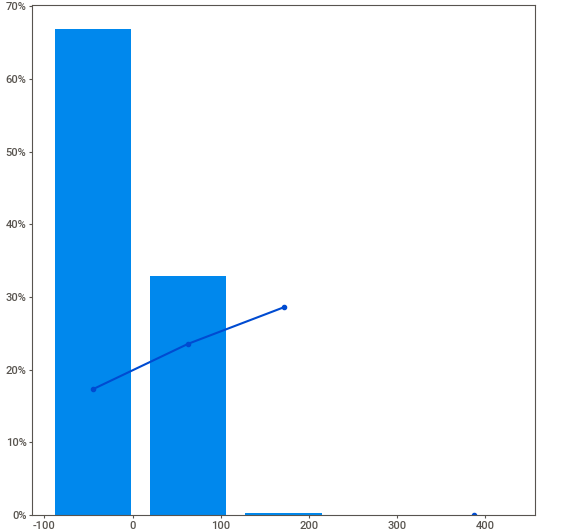
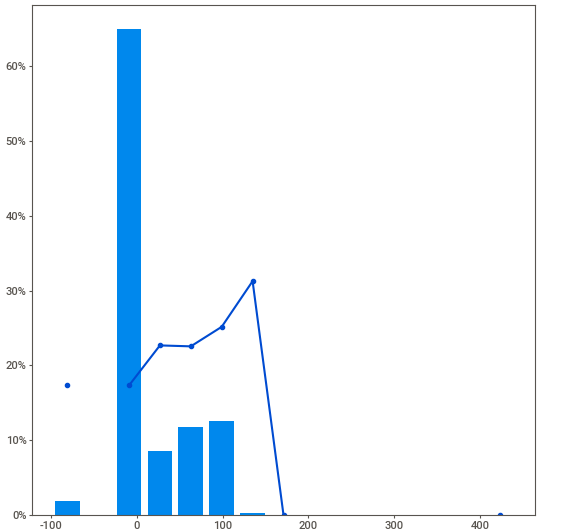
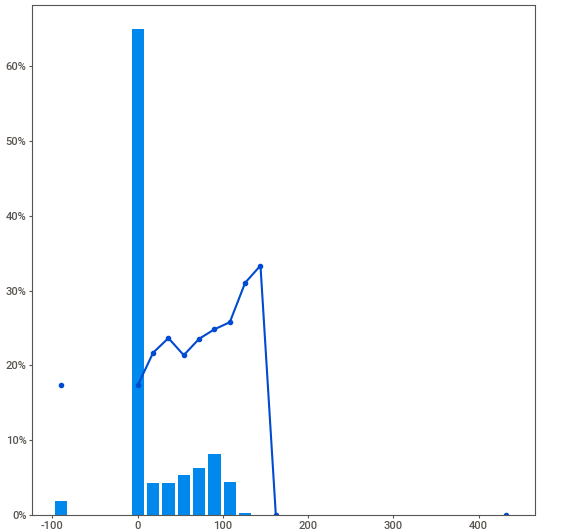
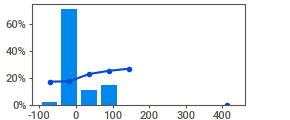
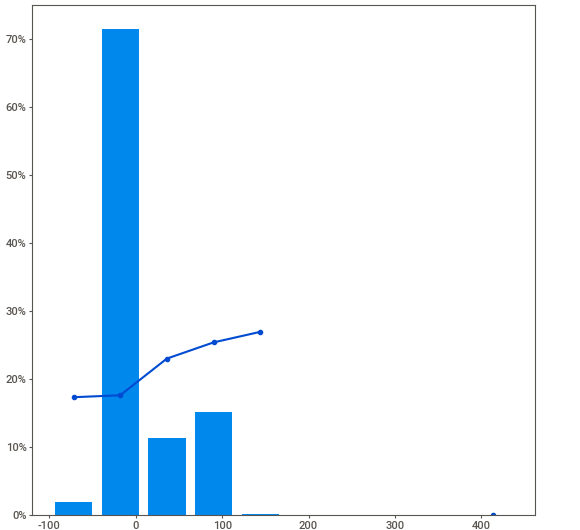
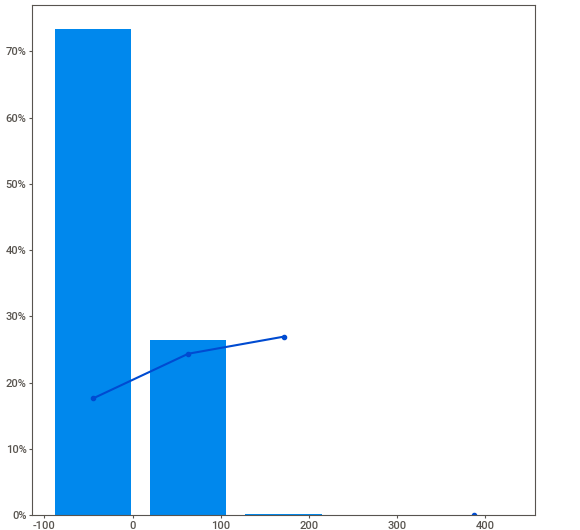
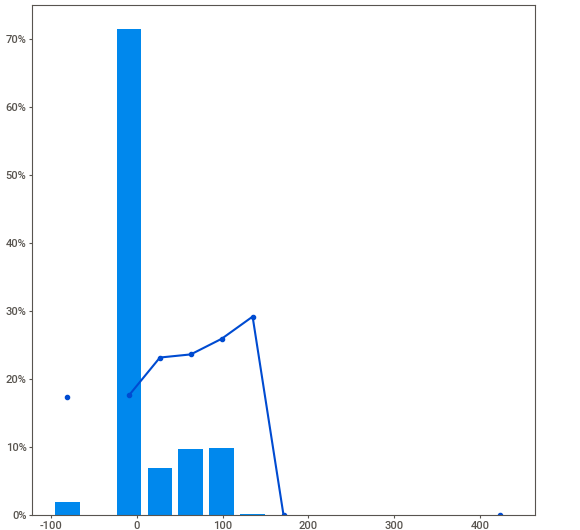
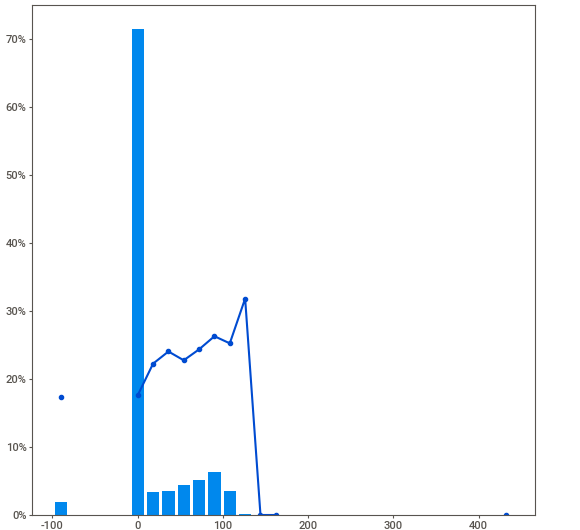
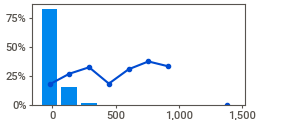
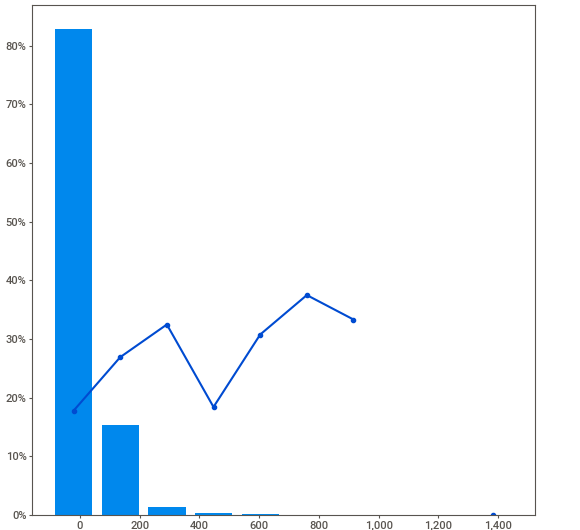
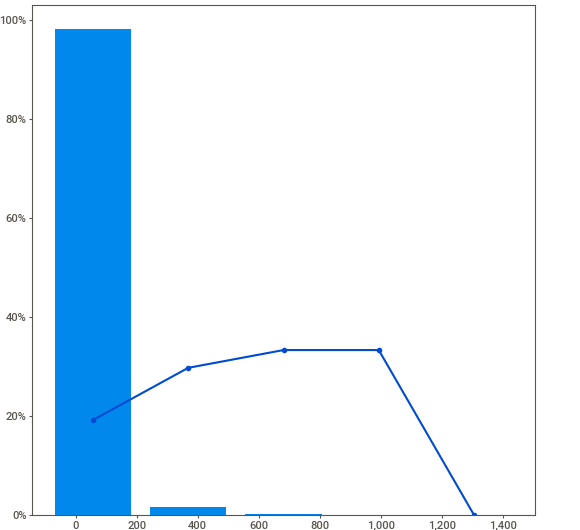
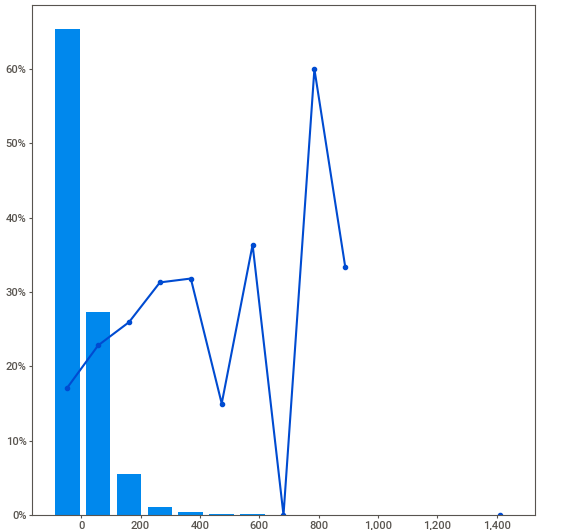
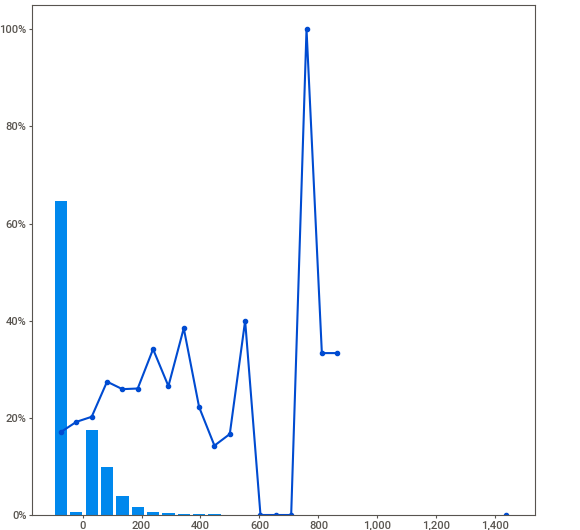
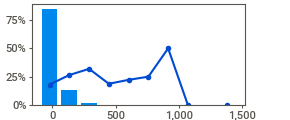
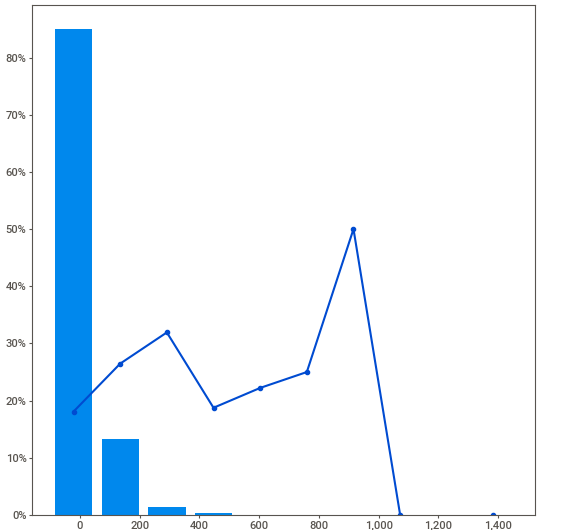
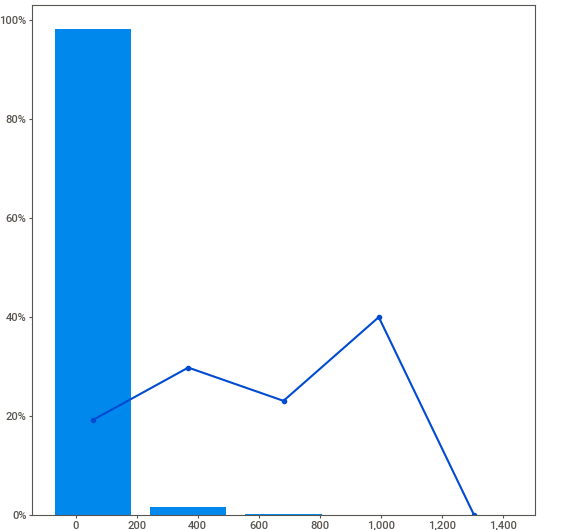
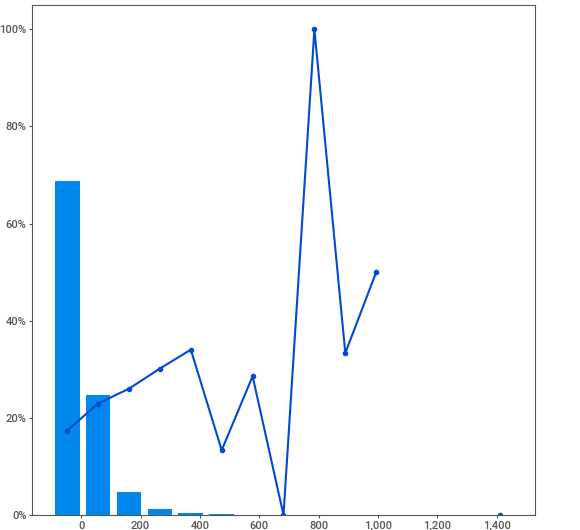
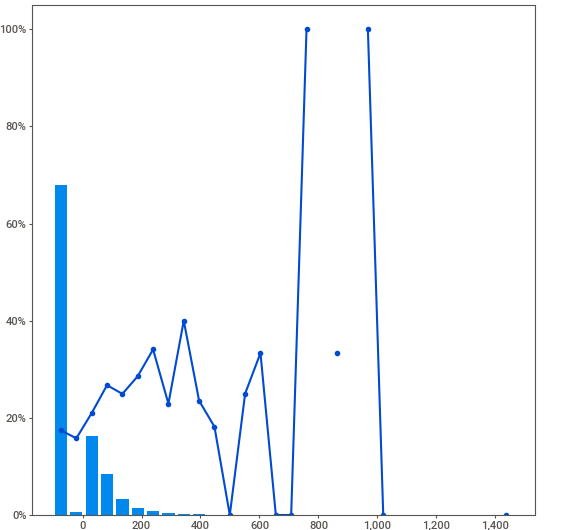
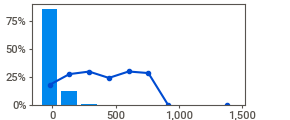
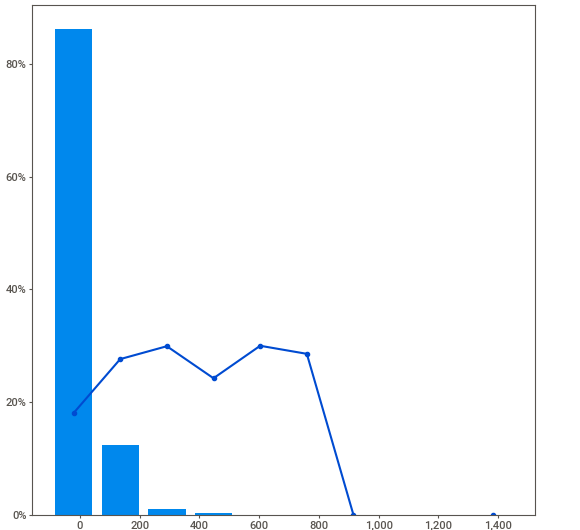
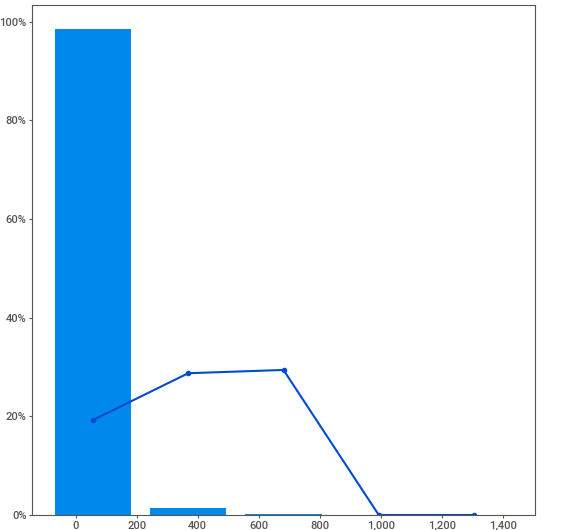
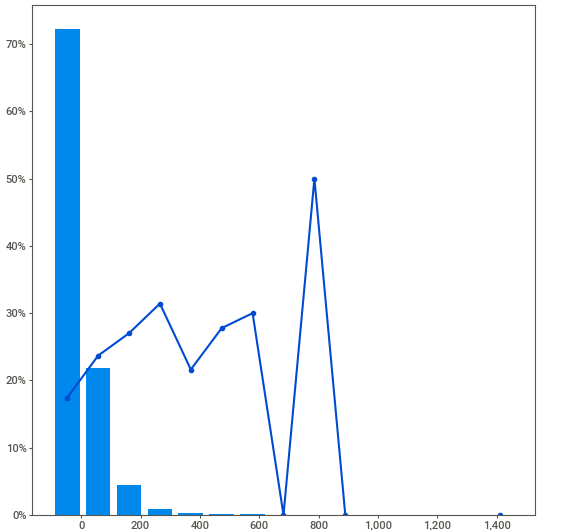
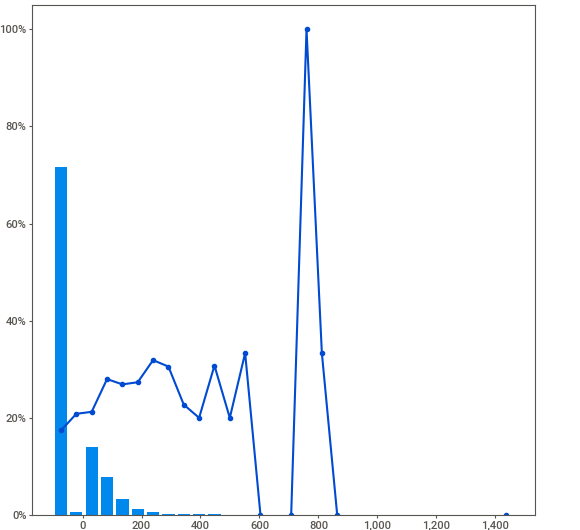
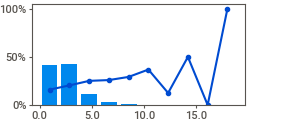
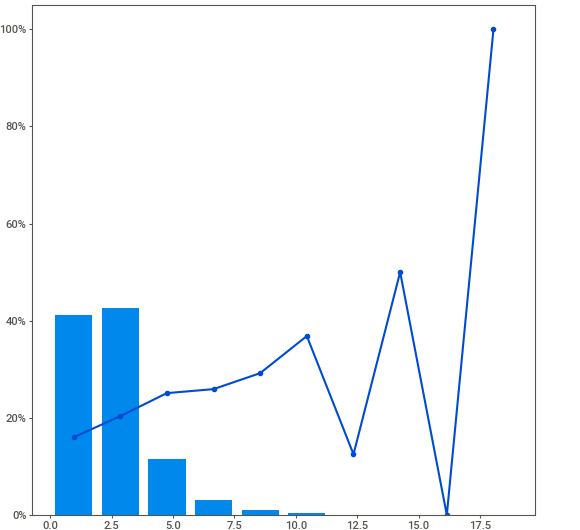
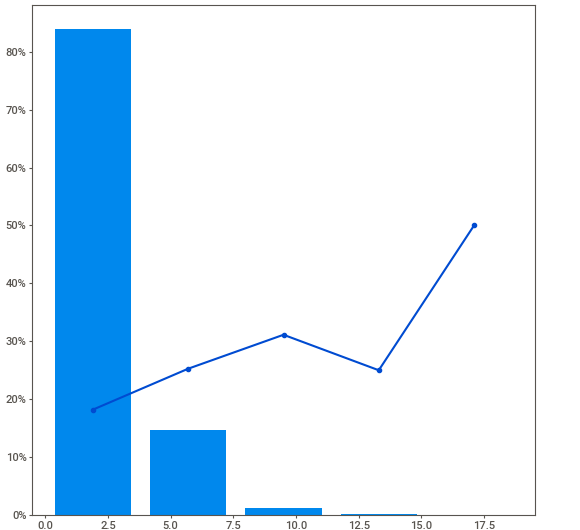
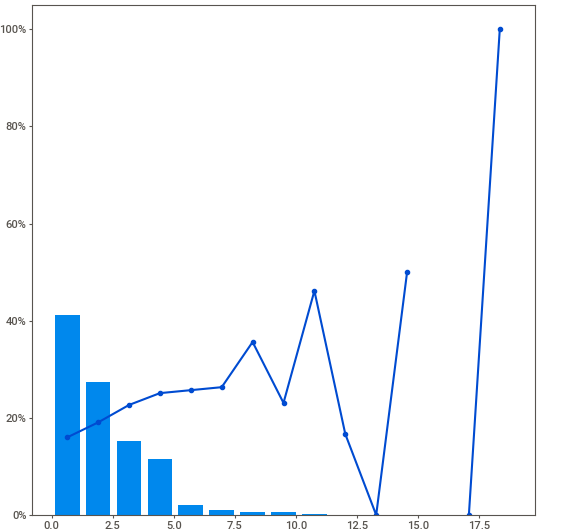
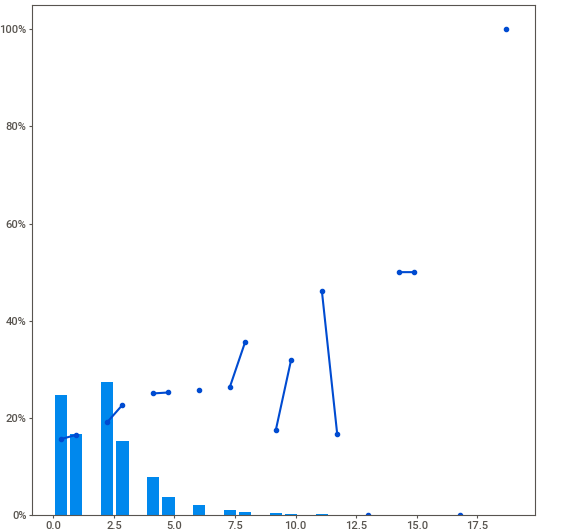
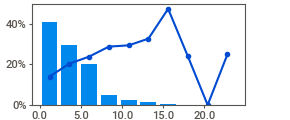
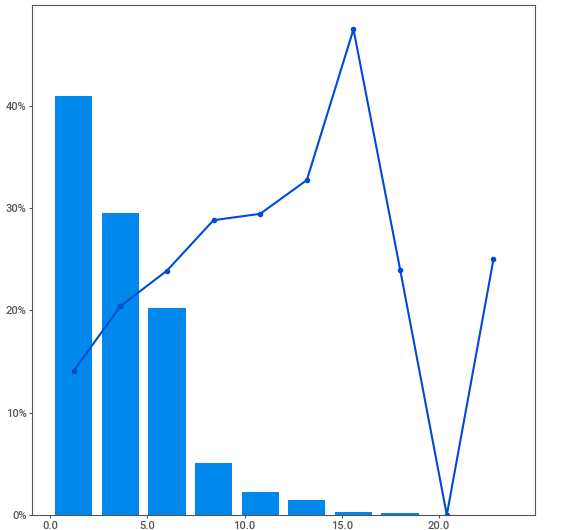
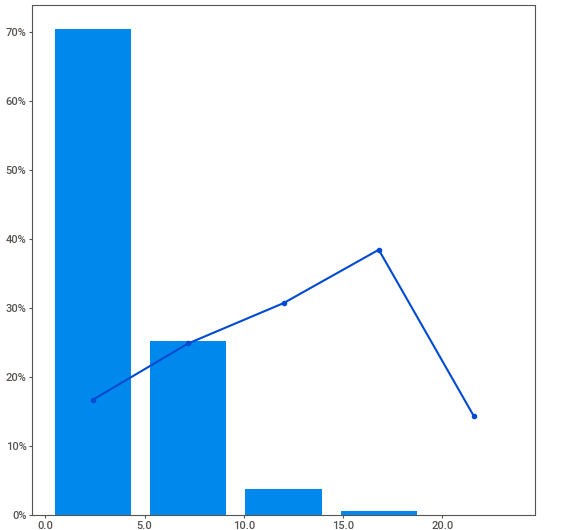
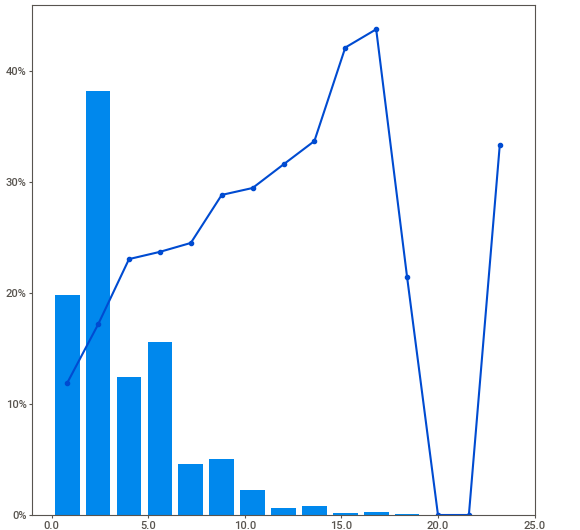
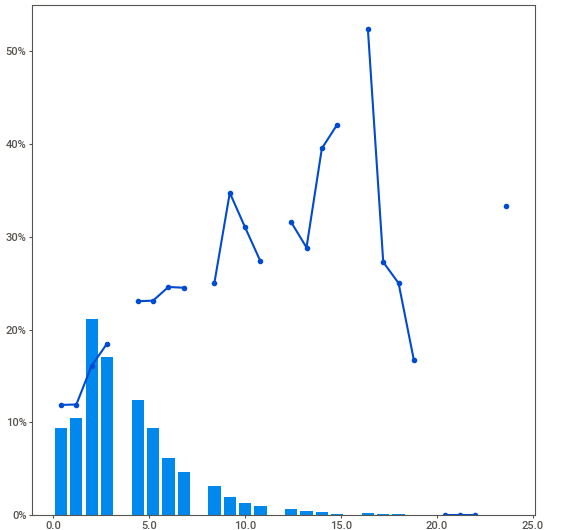
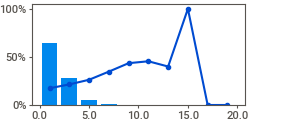
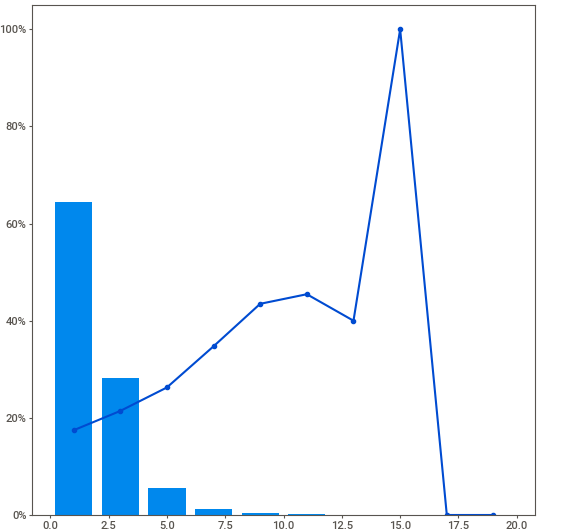
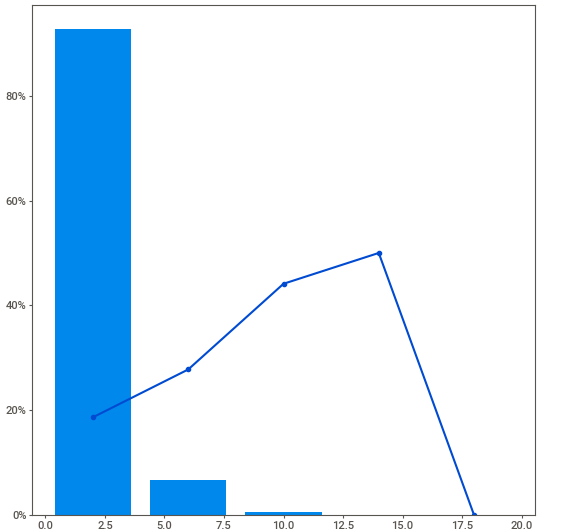
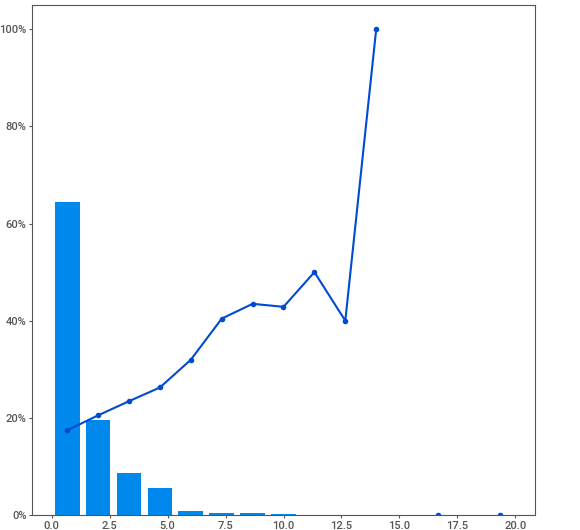
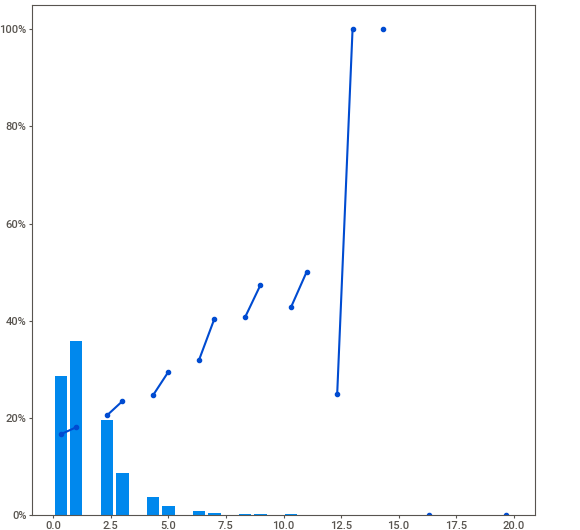
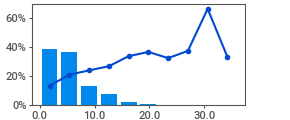
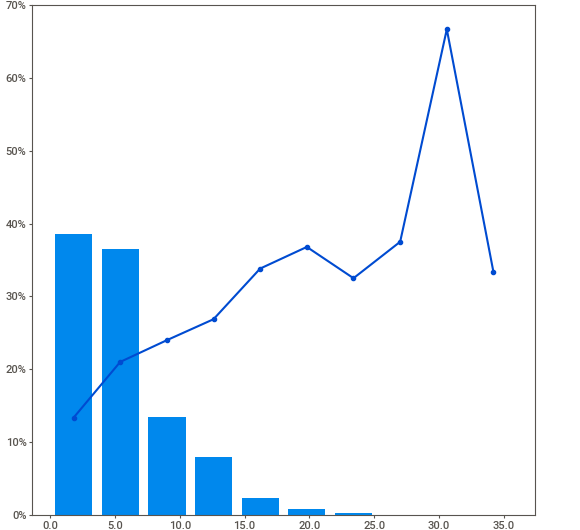
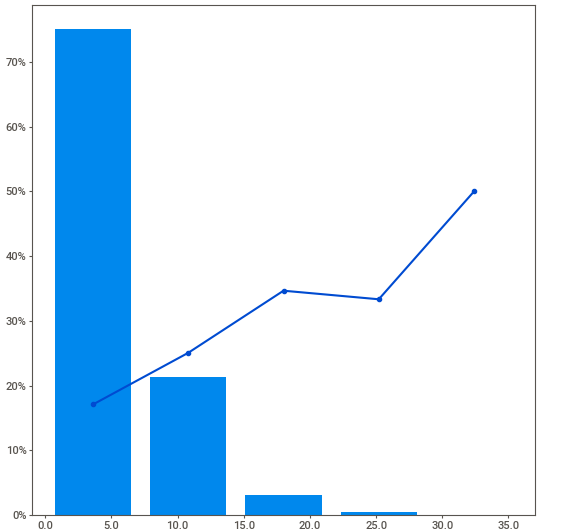
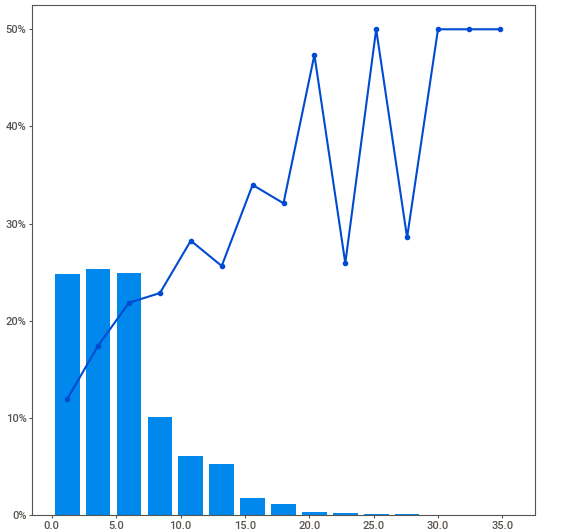
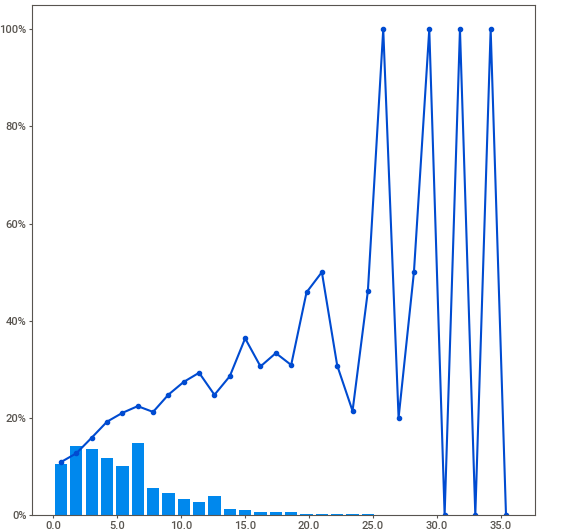
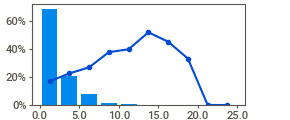
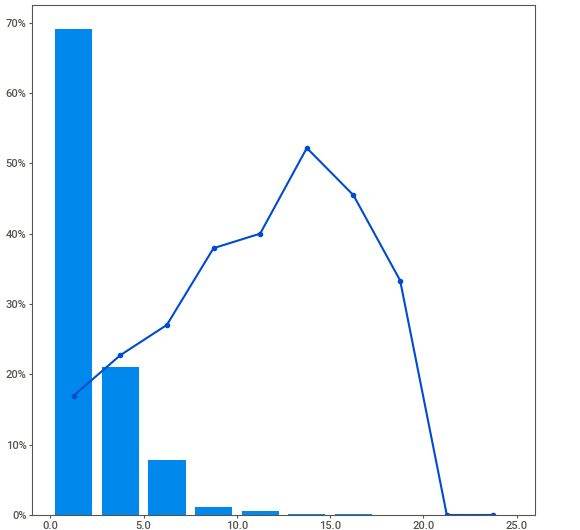
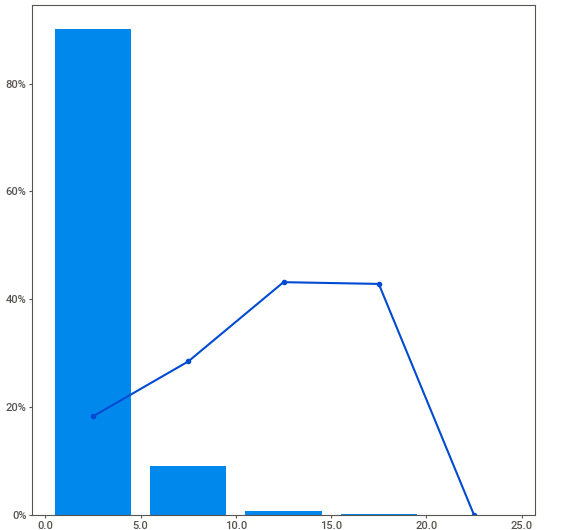
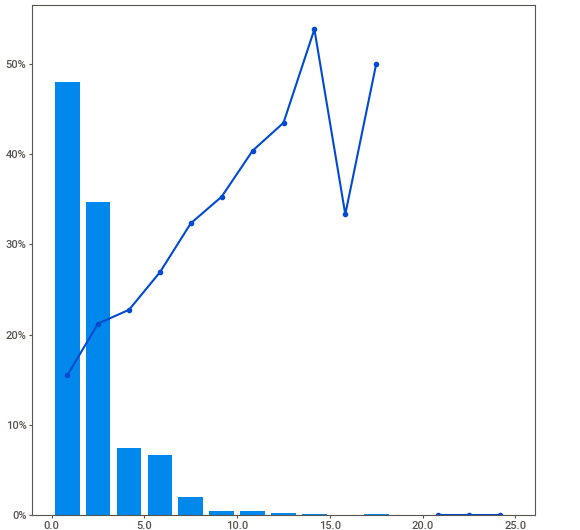
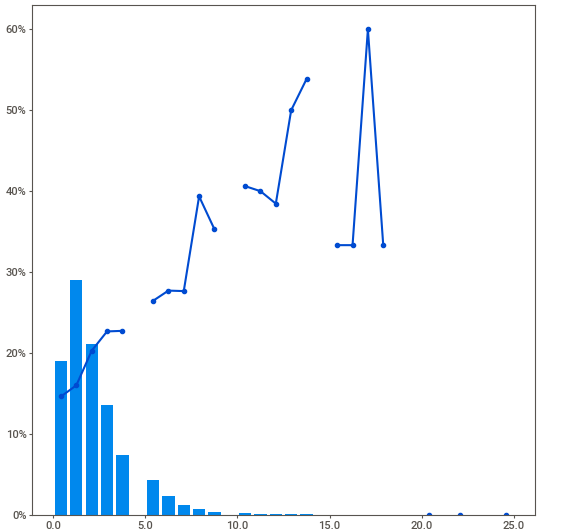
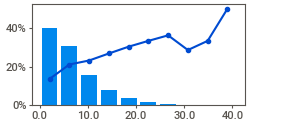
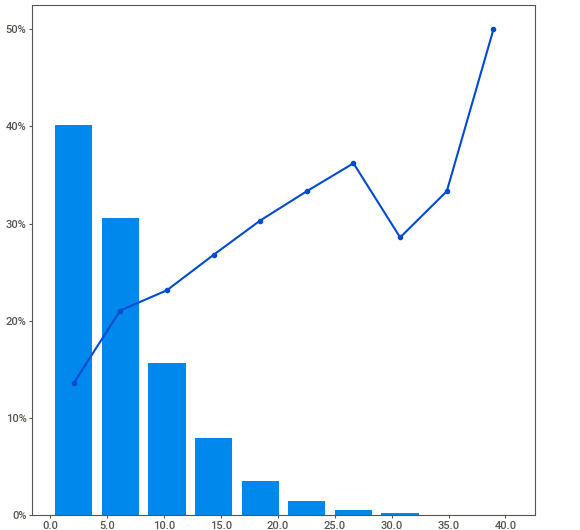
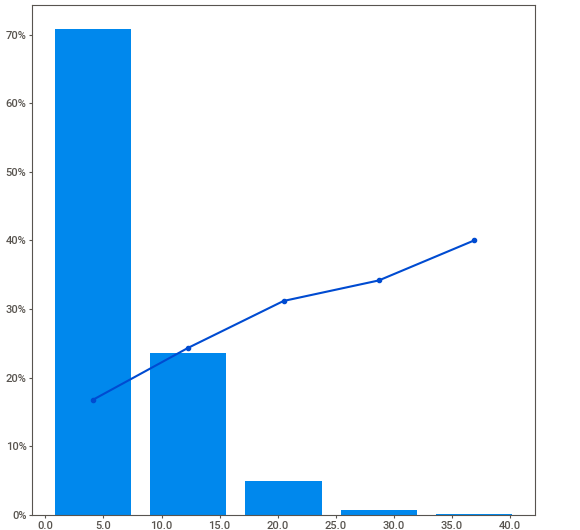
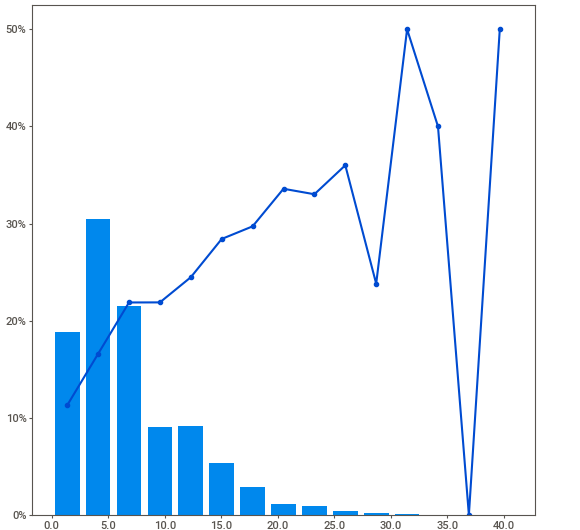
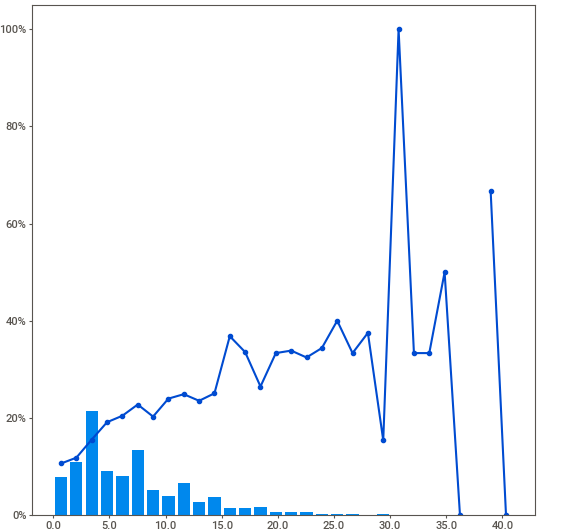
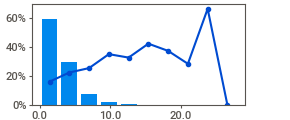
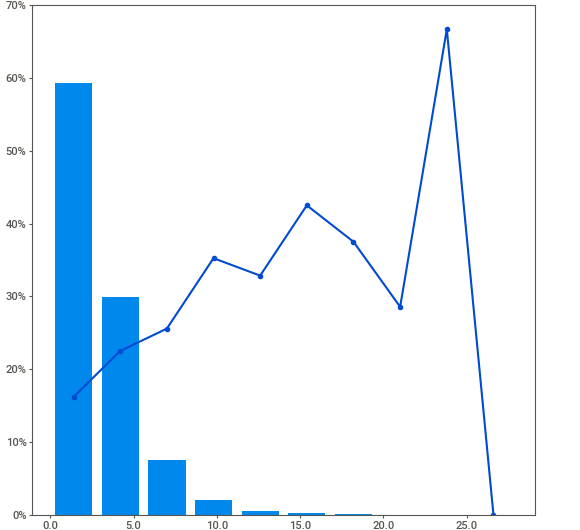
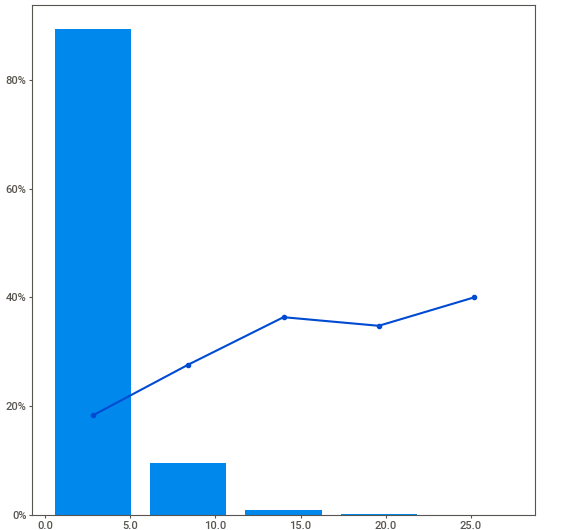
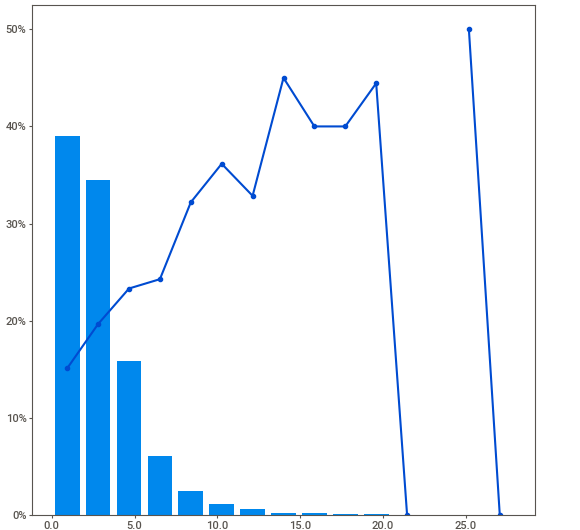
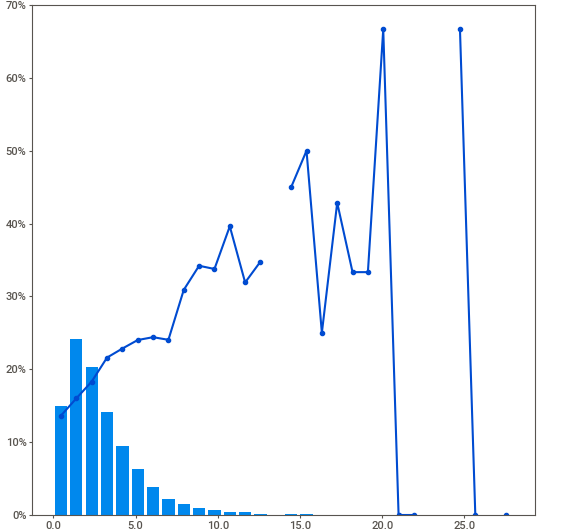
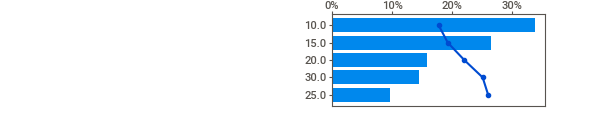
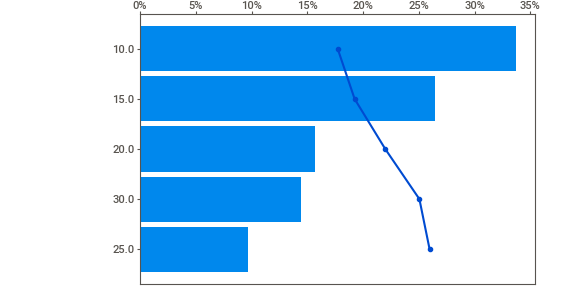
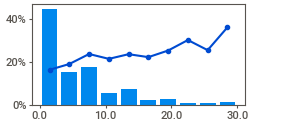
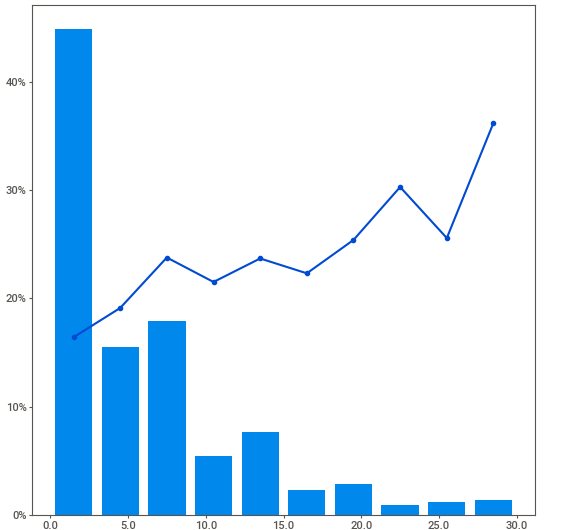
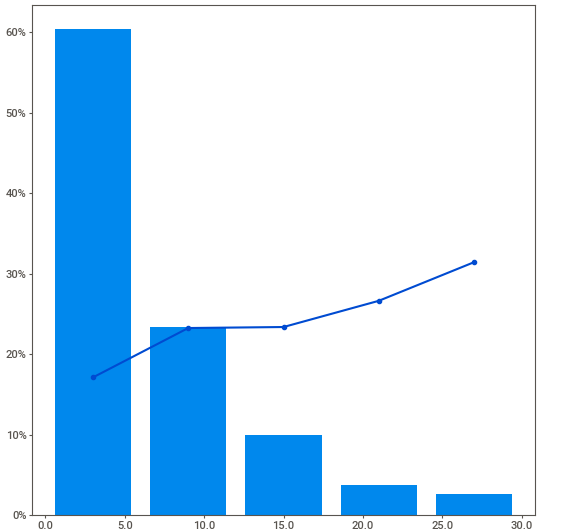
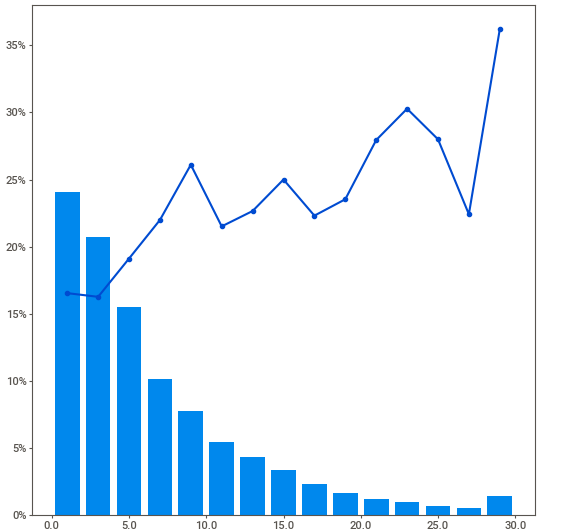
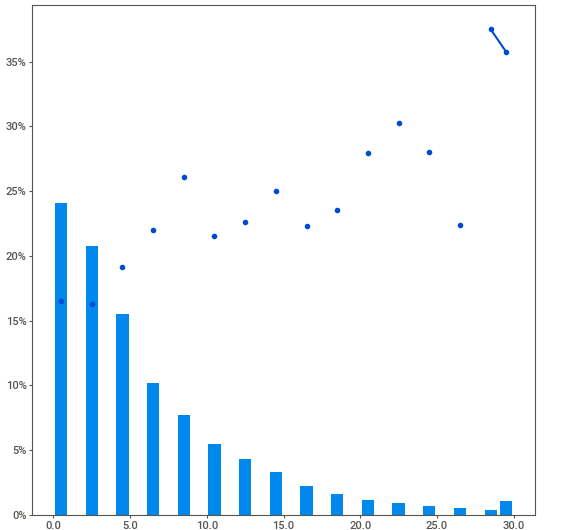
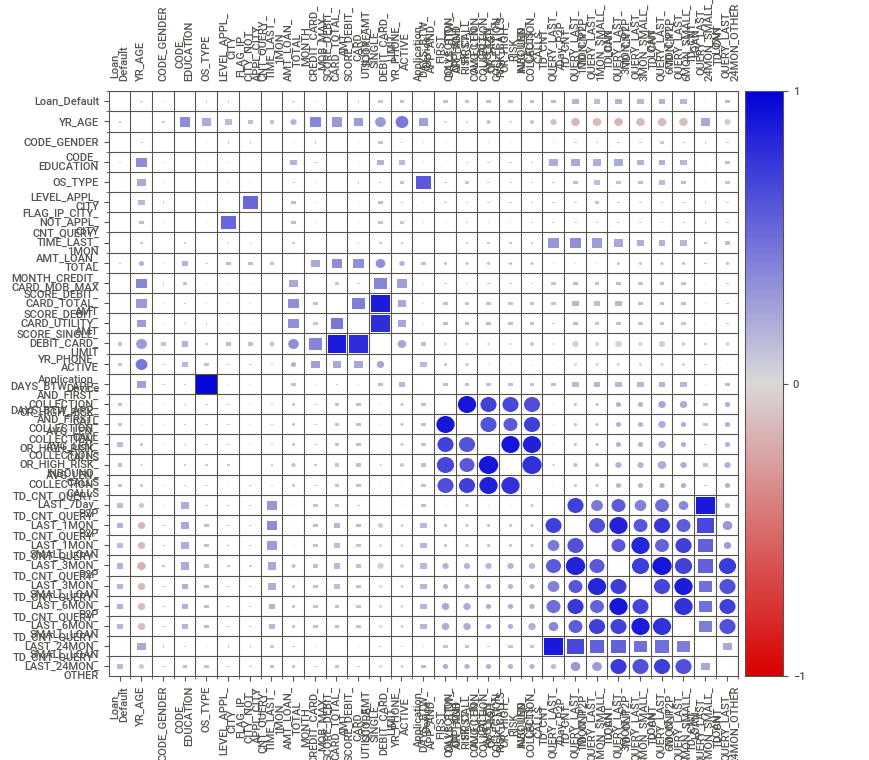
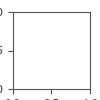

In [15]:
my_report = sv.analyze(train, target_feat=target)
my_report.show_html('report.html')
my_report.show_notebook()

### Reort Summary and Insights

Here’s a concise Sweetviz report summary for your dataset:

According to Sweetviz report, the dataset contains 16,000 rows and 29 columns, with a mix of numeric, categorical, and binary variables. The target variable is Loan_Default (0 = no default, 1 = default), which is imbalanced, with defaults making up a smaller proportion of cases.
- Numeric variables: Many features such as YR_AGE, AMT_LOAN_TOTAL, and credit-related query counts (TD_CNT_QUERY_LAST_*) show a right-skewed distribution, with a majority of values clustered near the lower range and a long tail of higher values. Several numeric variables (YR_PHONE_ACTIVE, TD_CNT_QUERY_LAST_24MON_SMALL_LOAN, TD_CNT_QUERY_LAST_24MON_OTHER, and some call duration features) have missing values that will need imputation.
- Categorical variables: OS_TYPE and Application_Device contain a small number of distinct categories. Some categorical variables are encoded as integers (CODE_GENDER, CODE_EDUCATION) but represent discrete classes.
- Correlations: Strong positive correlations exist among related credit query count variables (e.g., TD_CNT_QUERY_LAST_3MON_P2P and TD_CNT_QUERY_LAST_6MON_P2P). Loan amount and age have weaker correlations with the default outcome.
- Target relationships: Defaults tend to occur more in specific bins of numeric features (e.g., higher loan amounts, certain age ranges) and within certain OS or device categories.

Potential feature engineering opportunities:
- 1. Binning numeric variables like age, loan amount, and credit query counts.
- 2. Target encoding categorical variables, especially those with ordinal meaning (education code, gender code) and nominal meaning (OS type, application device).
- 3. Creating interaction features between call duration metrics and loan amounts or query counts.

Overall, the Sweetviz report highlights that the dataset is imbalanced, contains missing values, and has several highly skewed numeric features, all of which need addressing in preprocessing before modeling for best cumulative lift.

## 3. Feature Enhancement for Both Categorical and Numerical Variables

### Feature enhancement for the categorical variables - Target/mean encoding

In [16]:
# Show the code to use "target_encoder" for mean encoding
# Create a new set of mean-encoded variables for the categorical variables
# Use the X-train to get the mean first then apply to the test data.

from category_encoders import target_encoder as te
ec = te.TargetEncoder()

X_train_m = pd.DataFrame()
X_test_m = pd.DataFrame()

for var in cat_var:
    X_train_m[var+'_D'] = ec.fit_transform(X_train[var],y_train)
    X_test_m[var+'_D'] = ec.transform(X_test[var])

X_train_m

,OS_TYPE_D,Application_Device_D
8928,0.188905,0.189318
9895,0.188905,0.189318
14163,0.220118,0.245247
14352,0.180544,0.164782
15916,0.180544,0.178959
...,...,...
13123,0.188905,0.189318
3264,0.188905,0.189318
9845,0.188905,0.189318
10799,0.180544,0.178959


### Using iterativeimputer to handle missing values

In [17]:
# Find columns with missing values for the numerical columns
X_train_numvar = X_train[num_var]
missing_columns = X_train_numvar.columns[X_train_numvar.isnull().sum() > 0]

# Display the columns with missing values
missing_columns

Index(['YR_PHONE_ACTIVE',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL',
       'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS',
       'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS',
       'AVG_LEN_COLLECTION_CALLS', 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN',
       'TD_CNT_QUERY_LAST_24MON_OTHER'],
      dtype='object')

In [18]:
# Using iterativeimputer to handle missing values
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

# Initialize the imputer
iter_imputer = IterativeImputer(random_state=42)

# Fit on training data and transform both train and test
X_train[num_var] = iter_imputer.fit_transform(X_train[num_var])
X_test[num_var] = iter_imputer.transform(X_test[num_var])

### Feature enhancement for continuous variables

In [19]:
from category_encoders import TargetEncoder

# Numeric binning to categorical
num_bin_vars = {}
for var in num_var:
    # Bin into 5 quantiles (you can adjust number of bins)
    X_train[var+'_BIN'] = pd.qcut(X_train[var], q=5, duplicates='drop')
    X_test[var+'_BIN'] = pd.qcut(X_test[var], q=5, duplicates='drop')
    num_bin_vars[var+'_BIN'] = var

In [20]:
# Target encode the binned variables
te_bin = TargetEncoder()
X_train_bin_enc = pd.DataFrame()
X_test_bin_enc = pd.DataFrame()

for var in num_bin_vars.keys():
    X_train_bin_enc[var+'_D'] = te_bin.fit_transform(X_train[var], y_train)
    X_test_bin_enc[var+'_D'] = te_bin.transform(X_test[var])

In [44]:
# Drop known constant / bad columns before adding target
bad_cols = ["CODE_GENDER_BIN", "CODE_GENDER_BIN_D"]

X_train_model = X_train_model.drop(columns=bad_cols, errors='ignore')
X_test_model  = X_test_model.drop(columns=bad_cols, errors='ignore')

print("Dropped columns:", bad_cols)
print("Train shape after drop:", X_train_model.shape)
print("Test shape after drop:", X_test_model.shape)

Dropped columns: ['CODE_GENDER_BIN', 'CODE_GENDER_BIN_D']
Train shape after drop: (12000, 80)
Test shape after drop: (4000, 80)


### Combine all enhance features and prepare for modeling

In [45]:
target = "Loan_Default"

# Make sure target series has the right name
y_train = y_train.rename(target)
y_test = y_test.rename(target)

# Combine features + target into train_model and test_model
train_model = pd.concat([X_train_model, y_train.reset_index(drop=True)], axis=1)
test_model  = pd.concat([X_test_model,  y_test.reset_index(drop=True)], axis=1)

print("Target in train_model?", target in train_model.columns)  # should be True
print(train_model.shape, test_model.shape)

Target in train_model? True
(12000, 81) (4000, 81)


### Over-sampling

In [46]:
# Assume your modeling datasets are train_model and test_model
minority = train_model[train_model[target]==1]
majority = train_model[train_model[target]==0]

# Sample with replacement to reach the target
factor = 3 # Make the minority three times
n_to_sample = int(factor * len(minority))
oversampled = minority.sample(n=n_to_sample, replace=True, random_state=42)
print(len(majority), len(minority), len(oversampled))

9670 2330 6990


In [47]:
train_model = pd.concat([majority,oversampled],axis=0)
train_model.shape

(16660, 81)

### Summary of feature enhancement

For feature enhancement, categorical variables were transformed to improve model interpretability and predictive power. Techniques such as target encoding were applied, where each category was replaced with the mean target value, allowing the model to capture category–target relationships more effectively. For numerical variables, binning was used to convert continuous values into discrete intervals based on quantiles, capturing non-linear patterns and reducing the impact of outliers. These binned variables were further target encoded to introduce target-related information while maintaining discretization benefits. Together, these transformations enriched the feature space, enabling the model to better capture underlying patterns in both categorical and numerical data.

## 4. Apply H2O autoML to Build Best Model

### Initialize H2O

In [48]:
import h2o
from h2o.automl import H2OAutoML
# Start H2O cluster
h2o.init()

# Convert to H2O Frame
train_hex = h2o.H2OFrame(train_model)
test_hex = h2o.H2OFrame(test_model)
train_hex[target] = train_hex[target].asfactor()
test_hex[target] = test_hex[target].asfactor()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,4 days 23 hours 6 mins
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,4 months and 12 days
H2O_cluster_name:,H2O_from_python_yilin_em9g91
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.227 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


### Modeling using H2O

In [49]:
from h2o.automl import H2OAutoML

target = 'Loan_Default'

# Run H2O AutoML with class balancing enabled
aml = H2OAutoML(max_models=30, seed=1, balance_classes=True)
aml.train(y=target, training_frame=train_hex)

# View leaderboard
lb = aml.leaderboard
print(lb)

# Make predictions on test data
preds = aml.leader.predict(test_hex)

AutoML progress: |
20:48:47.894: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%
model_id                                                      auc    logloss     aucpr    mean_per_class_error      rmse        mse
StackedEnsemble_BestOfFamily_1_AutoML_7_20250808_204847  0.967918   0.155362  0.973406               0.042859   0.194229  0.037725
StackedEnsemble_AllModels_1_AutoML_7_20250808_204847     0.967899   0.155452  0.973418               0.0428073  0.194107  0.0376775
DRF_1_AutoML_7_20250808_204847                           0.967548   0.252167  0.972996               0.0513433  0.256247  0.0656625
GBM_grid_1_AutoML_7_20250808_204847_model_8              0.967106   0.162195  0.972919               0.0428469  0.197958  0.0391875
GBM_grid_1_AutoML_7_20250808_204847_model_5              0.966826   0.177978  0.972914               0.0435829  0.212146  0.0450057
GBM_grid_1_AutoML_7_20250808_204847_model_1        

In [50]:
# Achieve top models from H2O
aml.leaderboard.head(30)

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_BestOfFamily_1_AutoML_7_20250808_204847,0.967918,0.155362,0.973406,0.042859,0.194229,0.037725
StackedEnsemble_AllModels_1_AutoML_7_20250808_204847,0.967899,0.155452,0.973418,0.0428073,0.194107,0.0376775
DRF_1_AutoML_7_20250808_204847,0.967548,0.252167,0.972996,0.0513433,0.256247,0.0656625
GBM_grid_1_AutoML_7_20250808_204847_model_8,0.967106,0.162195,0.972919,0.0428469,0.197958,0.0391875
GBM_grid_1_AutoML_7_20250808_204847_model_5,0.966826,0.177978,0.972914,0.0435829,0.212146,0.0450057
GBM_grid_1_AutoML_7_20250808_204847_model_1,0.966589,0.17833,0.972276,0.0442309,0.211572,0.0447628
GBM_4_AutoML_7_20250808_204847,0.965579,0.186711,0.971906,0.0454874,0.21734,0.0472365
GBM_grid_1_AutoML_7_20250808_204847_model_4,0.965129,0.201057,0.971172,0.0477617,0.228374,0.0521546
GBM_3_AutoML_7_20250808_204847,0.964615,0.204822,0.970369,0.0522422,0.231309,0.0535038
XRT_1_AutoML_7_20250808_204847,0.963597,0.334214,0.967908,0.0719791,0.301494,0.0908984


### Select a top model

In [52]:
model_id = 'DRF_1_AutoML_7_20250808_204847'
my_best_model = h2o.get_model(model_id)
my_best_model.summary()

,number_of_trees,number_of_internal_trees,model_size_in_bytes,min_depth,max_depth,mean_depth,min_leaves,max_leaves,mean_leaves
,49.0,49.0,1352334.0,20.0,20.0,20.0,1994.0,2256.0,2136.7754


The best-performing model selected from the H2O AutoML process is a Distributed Random Forest (DRF) model, identified as DRF_1_AutoML_7_20250808_204847. This model consists of 49 trees, each corresponding to 49 internal trees, indicating that the model architecture is straightforward without additional ensemble stacking. The model has a size of approximately 1.35 MB, suggesting a relatively compact representation despite its complexity. Each tree in the model has a minimum, maximum, and mean depth of 20, indicating fully grown trees with consistent depth across the forest. The leaf statistics show a minimum of 1,994 leaves, a maximum of 2,256 leaves, and an average of about 2,137 leaves per tree, reflecting a high level of granularity in decision boundaries, which allows the model to capture intricate patterns in the data. This structure suggests the DRF model is designed for strong predictive capability while maintaining reasonable computational efficiency.

In [53]:
# Predict on test data
preds = aml.leader.predict(test_hex)
# Get performance metrics on test set
perf = aml.leader.model_performance(test_hex)
# Print common regression metrics
print("RMSE:", perf.rmse())
#print("MAE :", perf.mae())
print("R2  :", perf.r2())
print("MSE :", perf.mse())

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
RMSE: 0.4029643345232626
R2  : -0.07027855934968641
MSE : 0.16238025489777588


### Save the models

In [56]:
import os
save_dir = "/Users/yilin/Downloads/AnomalyDetection/h2o_models"
os.makedirs(save_dir, exist_ok=True)

# Faster conversion: multithreaded
# (pip install -U polars pyarrow to enable)
model_ids = (
    aml.leaderboard["model_id"]
      .as_data_frame(use_multi_thread=True)  # <- no warning, faster
      .iloc[:, 0]
      .tolist()
)

for mid in model_ids:
    model = h2o.get_model(mid)
    path = h2o.save_model(model=model, path=save_dir, force=True)
    print(f"Saved model {mid} to: {path}")

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Saved model StackedEnsemble_BestOfFamily_1_AutoML_7_20250808_204847 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/StackedEnsemble_BestOfFamily_1_AutoML_7_20250808_204847
Saved model StackedEnsemble_AllModels_1_AutoML_7_20250808_204847 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/StackedEnsemble_AllModels_1_AutoML_7_20250808_204847
Saved model DRF_1_AutoML_7_20250808_204847 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/DRF_1_AutoML_7_20250808_204847
Saved model GBM_grid_1_AutoML_7_20250808_204847_model_8 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/GBM_grid_1_AutoML_7_20250808_204847_model_8
Saved model GBM_grid_1_AutoML_7_20250808_204847_model_5 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/GBM_grid_1_AutoML_7_20250808_204847_model_5
Saved model GBM_grid_1_AutoML_7_20250808_204847_model_1 to: /Users/yilin/Downloads/AnomalyDetection/h2o_models/GBM

### Load the models

In [61]:
model_dir = "/Users/yilin/Downloads/AnomalyDetection/h2o_models"
loaded_models = []

for mid in model_ids:
    path = os.path.join(model_dir, mid)  # full model path
    try:
        model = h2o.load_model(path)
        loaded_models.append(model)
        print(f"Loaded: {model.model_id}")
    except Exception as e:
        print(f"Could not load {mid}: {e}")

Loaded: StackedEnsemble_BestOfFamily_1_AutoML_7_20250808_204847
Loaded: StackedEnsemble_AllModels_1_AutoML_7_20250808_204847
Loaded: DRF_1_AutoML_7_20250808_204847
Loaded: GBM_grid_1_AutoML_7_20250808_204847_model_8
Loaded: GBM_grid_1_AutoML_7_20250808_204847_model_5
Loaded: GBM_grid_1_AutoML_7_20250808_204847_model_1
Loaded: GBM_4_AutoML_7_20250808_204847
Loaded: GBM_grid_1_AutoML_7_20250808_204847_model_4
Loaded: GBM_3_AutoML_7_20250808_204847
Loaded: XRT_1_AutoML_7_20250808_204847
Loaded: GBM_2_AutoML_7_20250808_204847
Loaded: GBM_1_AutoML_7_20250808_204847
Loaded: GBM_5_AutoML_7_20250808_204847
Loaded: GBM_grid_1_AutoML_7_20250808_204847_model_3
Loaded: DeepLearning_grid_2_AutoML_7_20250808_204847_model_1
Loaded: DeepLearning_grid_3_AutoML_7_20250808_204847_model_1
Loaded: DeepLearning_grid_1_AutoML_7_20250808_204847_model_1
Loaded: DeepLearning_grid_3_AutoML_7_20250808_204847_model_4
Loaded: DeepLearning_grid_1_AutoML_7_20250808_204847_model_4
Loaded: GBM_grid_1_AutoML_7_20250808_

In [59]:
my_model = loaded_models[2]
my_model

Model Details
=============
H2ORandomForestEstimator : Distributed Random Forest
Model Key: DRF_1_AutoML_7_20250808_204847


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    49                 49                          1.35233e+06            20           20           20            1994          2256          2136.78

ModelMetricsBinomial: drf
** Reported on train data. **

MSE: 0.04226771326893809
RMSE: 0.20559113129932938
LogLoss: 0.17929746479668496
Mean Per-Class Error: 0.022664705135306176
AUC: 0.9915292794307077
AUCPR: 0.99420382862489
Gini: 0.9830585588614154

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.5455692652841844
       0     1     Error    Rate
-----  ----  ----  -------  ---------------
0      9553  117   0.0121   (117.0/9670.0)
1      322   9368  0.0332   (322.0/9690.0)
Total  9875  9485  0.0227   (439.0/19360.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.545569     0.977106  182
max f2                       0.456956     0.974702  207
max f0point5                 0.607178     0.987036  166
max accuracy                 0.545569     0.977324  182
max precision                1            1         0
max recall                   1.25549e-05  1         399
max specificity              1            1         0
max absolute_mcc             0.545569     0.954864  182
max min_per_class_accuracy   0.493133     0.973684  196
max mean_per_class_accuracy  0.545569     0.977335  182
max tns                      1            9670      0
max fns                      1            7437      0
max fps                      1.25549e-05  9670      399
max tps                      1.25549e-05  9690      399
max tnr                      1            1         0
max fnr                      1            0.767492  0
max fpr                      1.25549e-05  1         399
max tpr                      1.25549e-05  1         399

Gains/Lift Table: Avg response rate: 50.05 %, avg score: 55.60 %
group    cumulative_data_fraction    lower_threshold    lift       cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ---------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.116322                    1                  1.99794    1.99794            1                1          1                           1                   0.232405        0.232405                   99.7936   99.7936            0.232405
2        0.15                        0.991852           1.99794    1.99794            1                0.995091   1                           0.998898            0.0672859       0.29969                    99.7936   99.7936            0.29969
3        0.2                         0.981487           1.99794    1.99794            1                0.987088   1                           0.995945            0.0998968       0.399587                   99.7936   99.7936            0.399587
4        0.3                         0.938748           1.99794    1.99794            1                0.963812   1                           0.985234            0.199794        0.599381                   99.7936   99.7936            0.599381
5        0.4                         0.861275           1.99794    1.99794            1                0.907068   1                           0.9

### Prediction

In [67]:
# Get predictions (returns an H2OFrame with class and probs)
preds = my_model.predict(test_hex).as_data_frame()
# View the frame
preds.head()

drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/opt/anaconda3/envs/Anomalydetection/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,predict,p0,p1
0,0,0.722949,0.277051
1,0,0.743898,0.256102
2,0,0.860358,0.139642
3,0,0.827256,0.172744
4,0,0.646275,0.353725


In [68]:
# Extract the probability of class 1
best_model_probs = preds['p1']
best_model_probs.head()

0    0.277051
1    0.256102
2    0.139642
3    0.172744
4    0.353725
Name: p1, dtype: float64

In [70]:
best_model_pred = preds['predict']
best_model_pred.head()

0    0
1    0
2    0
3    0
4    0
Name: predict, dtype: int64

## 5. Model Performance

### Accuracy

In [71]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
print('The test data:',accuracy_score(y_test,best_model_pred))

The test data: 0.813


### Confusion Matrix

In [72]:
best_cm = pd.DataFrame(confusion_matrix(y_test,best_model_pred))
best_cm.rename(columns={0:'Predicted Negative', 1:'Predicted Positive'},
         index = {0:'Actual Negative',1:'Actual Positive'},inplace=True)
best_cm

,Predicted Negative,Predicted Positive
Actual Negative,3251,3
Actual Positive,745,1


### AUC-ROC

In [73]:
best_roc_auc_value = roc_auc_score(y_test,best_model_probs)
best_roc_auc_value

0.6208263370633956

### Plot ROC Curve

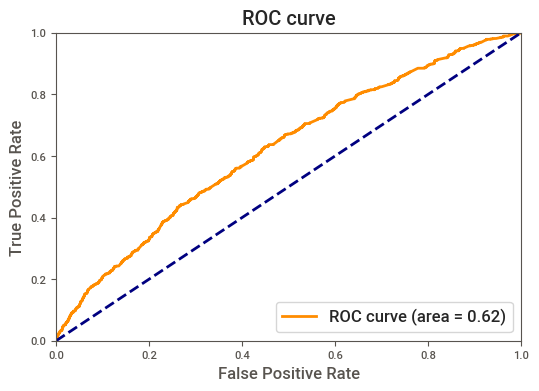

In [74]:
def plot_roc(y_true,y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = roc_auc_score(y_true,y_prob)
    lw=2
    plt.figure(figsize=(6,4))
    plt.plot(fpr,tpr, color='darkorange',lw=lw,label='ROC curve (area = %0.2f)' %roc_auc_value)
    plt.plot([0,1],[0,1], color='navy',lw=lw,linestyle='--')
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.legend(loc='lower right')
    plt.show()
    
plot_roc(y_test, best_model_probs)

### The Prediction-Recall Curve


   * ROC curve: The ROC curve plots the true positive rate vs. the false rositive sate

	  * The area under the curve (AUC): A value between 0.5 (random) and 1.0 (perfect), measuring the prediction accuracy

   * Recall (R) = The number of true positives / (the number of true positives + the number of false negatives)



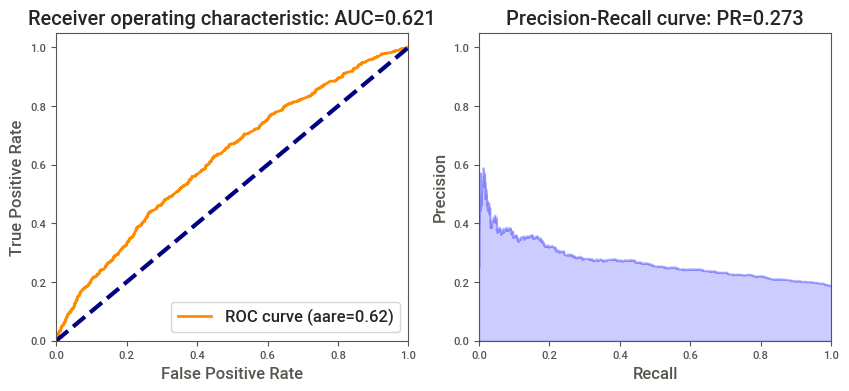

In [75]:
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_recall_curve

def ROC_PR(y_actual, y_pred):
    # ROC
    fpr = list()
    tpr = list()
    roc_auc = list()
    fpr,tpr,_ = roc_curve(y_actual,y_pred)
    roc_auc = auc(fpr,tpr)
    
    # Precision-Recall
    average_precision = average_precision_score(y_actual,y_pred)

    print('')
    print('   * ROC curve: The ROC curve plots the true positive rate vs. the false rositive sate')
    print('')
    print('	  * The area under the curve (AUC): A value between 0.5 (random) and 1.0 (perfect), measuring the prediction accuracy')
    print('')
    print('   * Recall (R) = The number of true positives / (the number of true positives + the number of false negatives)')
    print('')
    
    # plotting
    plt.figure(figsize=(10,4))

    # ROC
    plt.subplot(1,2,1)
    plt.plot(fpr,tpr,color='darkorange',lw=2,label='ROC curve (aare=%0.2f)' % roc_auc)
    plt.plot([0,1],[0,1],color='navy',lw=3,linestyle='--')
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic: AUC={0:0.3f}'.format(roc_auc))
    plt.legend(loc='lower right')

    # Precision-Recall
    plt.subplot(1,2,2)
    precision,recall,_ = precision_recall_curve(y_actual,y_pred)
    plt.step(recall,precision,color='b',alpha=0.2,where='post')
    plt.fill_between(recall,precision,step='post',alpha=0.2,color='b')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0,1.05])
    plt.xlim([0.0,1.0])
    plt.title('Precision-Recall curve: PR={0:0.3f}'.format(average_precision))
    plt.show()
    
ROC_PR(y_test,best_model_probs)

### The F1 Score

In [76]:
from sklearn.metrics import f1_score
# Calculate the F1 score
f1 = f1_score(y_test, best_model_pred)  # y_test is the actual, test_pred is the prediction
print("F1 Score:", f1)

F1 Score: 0.0026666666666666666


### The Gains Table

In [78]:
def gains_table_profit(Y_test,y_pred):
    df_prep = pd.DataFrame(columns = ['actual','pred'])
    df_prep['actual'] = Y_test.values
    df_prep['pred'] =y_pred.values
    df_prep = df_prep.sort_values(by='pred',ascending=False)
    df_prep['row_id'] = range(0,0+len(df_prep))
    df_prep.head()

    df_prep['decile'] = (df_prep['row_id'] / (len(df_prep)/10)).astype(int)
    df_prep.loc[df_prep['decile'] == 10] =9
    df_prep['decile'].value_counts()

    # Create gains table
    gains = df_prep.groupby('decile')['actual'].agg(['count','sum'])
    gains.columns = ['count','actual']
    gains

    gains['non_actual'] = gains['count'] - gains['actual']
    gains['cum_count'] = gains['count'].cumsum()
    gains['cum_actual'] = gains['actual'].cumsum()
    gains['cum_non_actual'] = gains['non_actual'].cumsum()
    gains['percent_cum_actual'] = (gains['cum_actual'] / np.max(gains['cum_actual'])).round(2)
    gains['percent_cum_non_actual'] = (gains['cum_non_actual'] / np.max(gains['cum_non_actual'])).round(2)
    gains['if_random'] = np.max(gains['cum_actual']) /10
    gains['if_random'] = gains['if_random'].cumsum()
    gains['lift'] = (gains['cum_actual'] / gains['if_random']).round(2)
    gains['K_S'] = np.abs( gains['percent_cum_actual'] - gains['percent_cum_non_actual']  ) * 100 
    gains['gain'] = (gains['cum_actual'] / gains['cum_count']*100).round(2)
    gains['revenue'] = approved_load * irr *  gains['non_actual']
    gains['cost'] = approved_load *  gains['actual']
    gains['profit'] = gains['revenue'] - gains['cost']
    return(gains)
    
# Assume the following values
approved_load = 10000
irr = 0.10 # annual interest rate

best_gains = gains_table_profit(y_test,best_model_probs)
best_gains

,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,135,265,400,135,265,0.18,0.08,74.6,1.81,10.0,33.75,265000.0,1350000,-1085000.0
1,400,88,312,800,223,577,0.30,0.18,149.2,1.49,12.0,27.88,312000.0,880000,-568000.0
2,400,105,295,1200,328,872,0.44,0.27,223.8,1.47,17.0,27.33,295000.0,1050000,-755000.0
3,400,69,331,1600,397,1203,0.53,0.37,298.4,1.33,16.0,24.81,331000.0,690000,-359000.0
4,400,80,320,2000,477,1523,0.64,0.47,373.0,1.28,17.0,23.85,320000.0,800000,-480000.0
5,400,62,338,2400,539,1861,0.72,0.57,447.6,1.20,15.0,22.46,338000.0,620000,-282000.0
6,400,68,332,2800,607,2193,0.81,0.67,522.2,1.16,14.0,21.68,332000.0,680000,-348000.0
7,400,53,347,3200,660,2540,0.88,0.78,596.8,1.11,10.0,20.62,347000.0,530000,-183000.0
8,400,52,348,3600,712,2888,0.95,0.89,671.4,1.06,6.0,19.78,348000.0,520000,-172000.0


### The Cumulative Life Curve

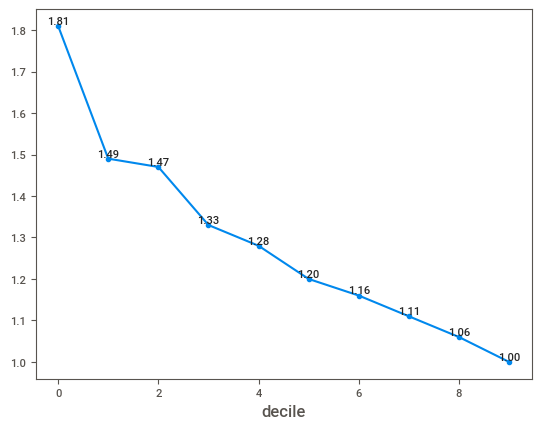

In [80]:
ax = best_gains['lift'].plot.line(marker='o')
for i, (x, y) in enumerate(zip(best_gains.index, best_gains['lift'])):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
plt.show()

### The Kolmogorov-Smirnov (K-S) statistic

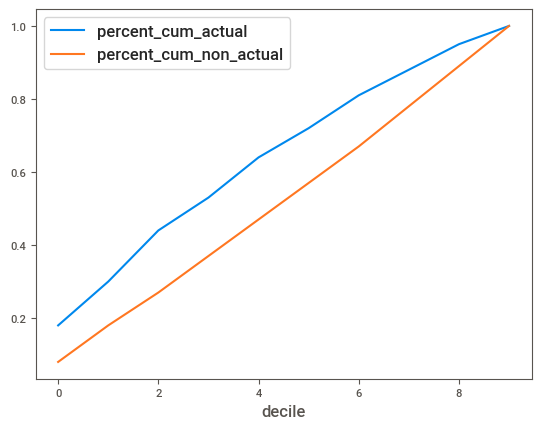

In [81]:
best_gains[['percent_cum_actual','percent_cum_non_actual']].plot.line()
plt.show()

### Model Performance Summary

The selected best model, a Distributed Random Forest (DRF) from H2O AutoML, demonstrates moderate predictive performance. It achieves an overall accuracy of 81.3% on the test dataset, but the confusion matrix reveals a significant class imbalance challenge: while the model correctly identifies most negative cases (True Negatives), it struggles to capture positive cases, with only 1 True Positive out of 746 actual positives. This imbalance is further reflected in the low F1 score of 0.0027, which highlights poor recall for the minority class despite high precision for the majority class. The AUC-ROC score of 0.62 suggests the model is moderately better than random guessing but far from optimal, as shown in the ROC curve’s modest separation from the diagonal baseline. The Precision-Recall curve also indicates limited precision at higher recall levels, confirming that minority-class prediction remains a weakness.

From a business perspective, the gains table shows that in the top decile, the model achieves a lift of 1.81, meaning it captures 81% more positive cases than random targeting. However, lift values decline steadily across deciles, indicating reduced model discrimination deeper into the population. The K-S statistic plot confirms moderate separation between positive and negative cumulative distributions, peaking in early deciles but narrowing thereafter.

To improve the lift curve score and overall minority-class detection, we can employ targeted strategies. First, resampling techniques such as SMOTE or random oversampling can help address the severe class imbalance, giving the model more positive cases to learn from. Second, adjusting the classification threshold based on business objectives (e.g., maximizing lift in the top deciles rather than accuracy) can enhance early-decile performance. Third, introducing stronger regularization and feature engineering — particularly features directly linked to loan default behavior — can improve model generalization and separation power. Lastly, trying alternative algorithms like Gradient Boosting Machines or XGBoost (once enabled) may yield stronger early-decile lifts due to their superior handling of complex decision boundaries.

## 6. Profit & Loss Calculations (P&L)

Assumptions
- Each approved loan is worth \$10,000.
- Approved loans have an annual interest rate of 10%, generating \$1,000 in revenue per loan per year.
- If a loan defaults, the bank loses the entire loan amount (\$10,000).

Profit calculation:
- If a loan is approved and does not default, the bank gains \$1,000 in interest revenue. 
- If a loan is approved and defaults, the bank loses \$10,000.
- Calculate the overall profit or loss across the test dataset.
- Total Revenue: Sum of gains from approved loans that do not default.
- Total Loss: Sum of losses from approved loans that default.
- Net Profit: Total Revenue - Total Loss.

What we do in this section:
- We will perform the P&L for interest rate at 4%, 8%, 12% and describe if that impacts our recommendation.

In [82]:
irr = 0.04 # annual interest rate
sensitivity = gains_table_profit(y_test,best_model_probs)
selected_profit = sensitivity[sensitivity['profit']>0]['profit'].sum()
print('The profits from the positive profit deciles is:', selected_profit)
sensitivity

The profits from the positive profit deciles is: 0.0


,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,135,265,400,135,265,0.18,0.08,74.6,1.81,10.0,33.75,106000.0,1350000,-1244000.0
1,400,88,312,800,223,577,0.30,0.18,149.2,1.49,12.0,27.88,124800.0,880000,-755200.0
2,400,105,295,1200,328,872,0.44,0.27,223.8,1.47,17.0,27.33,118000.0,1050000,-932000.0
3,400,69,331,1600,397,1203,0.53,0.37,298.4,1.33,16.0,24.81,132400.0,690000,-557600.0
4,400,80,320,2000,477,1523,0.64,0.47,373.0,1.28,17.0,23.85,128000.0,800000,-672000.0
5,400,62,338,2400,539,1861,0.72,0.57,447.6,1.20,15.0,22.46,135200.0,620000,-484800.0
6,400,68,332,2800,607,2193,0.81,0.67,522.2,1.16,14.0,21.68,132800.0,680000,-547200.0
7,400,53,347,3200,660,2540,0.88,0.78,596.8,1.11,10.0,20.62,138800.0,530000,-391200.0
8,400,52,348,3600,712,2888,0.95,0.89,671.4,1.06,6.0,19.78,139200.0,520000,-380800.0


In [83]:
irr = 0.08 # annual interest rate
sensitivity = gains_table_profit(y_test,best_model_probs)
selected_profit = sensitivity[sensitivity['profit']>0]['profit'].sum()
print('The profits from the positive profit deciles is:', selected_profit)
sensitivity

The profits from the positive profit deciles is: 0.0


,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,135,265,400,135,265,0.18,0.08,74.6,1.81,10.0,33.75,212000.0,1350000,-1138000.0
1,400,88,312,800,223,577,0.30,0.18,149.2,1.49,12.0,27.88,249600.0,880000,-630400.0
2,400,105,295,1200,328,872,0.44,0.27,223.8,1.47,17.0,27.33,236000.0,1050000,-814000.0
3,400,69,331,1600,397,1203,0.53,0.37,298.4,1.33,16.0,24.81,264800.0,690000,-425200.0
4,400,80,320,2000,477,1523,0.64,0.47,373.0,1.28,17.0,23.85,256000.0,800000,-544000.0
5,400,62,338,2400,539,1861,0.72,0.57,447.6,1.20,15.0,22.46,270400.0,620000,-349600.0
6,400,68,332,2800,607,2193,0.81,0.67,522.2,1.16,14.0,21.68,265600.0,680000,-414400.0
7,400,53,347,3200,660,2540,0.88,0.78,596.8,1.11,10.0,20.62,277600.0,530000,-252400.0
8,400,52,348,3600,712,2888,0.95,0.89,671.4,1.06,6.0,19.78,278400.0,520000,-241600.0


In [84]:
irr = 0.12 # annual interest rate
sensitivity = gains_table_profit(y_test,best_model_probs)
selected_profit = sensitivity[sensitivity['profit']>0]['profit'].sum()
print('The profits from the positive profit deciles is:', selected_profit)
sensitivity

The profits from the positive profit deciles is: 99200.0


,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,135,265,400,135,265,0.18,0.08,74.6,1.81,10.0,33.75,318000.0,1350000,-1032000.0
1,400,88,312,800,223,577,0.30,0.18,149.2,1.49,12.0,27.88,374400.0,880000,-505600.0
2,400,105,295,1200,328,872,0.44,0.27,223.8,1.47,17.0,27.33,354000.0,1050000,-696000.0
3,400,69,331,1600,397,1203,0.53,0.37,298.4,1.33,16.0,24.81,397200.0,690000,-292800.0
4,400,80,320,2000,477,1523,0.64,0.47,373.0,1.28,17.0,23.85,384000.0,800000,-416000.0
5,400,62,338,2400,539,1861,0.72,0.57,447.6,1.20,15.0,22.46,405600.0,620000,-214400.0
6,400,68,332,2800,607,2193,0.81,0.67,522.2,1.16,14.0,21.68,398400.0,680000,-281600.0
7,400,53,347,3200,660,2540,0.88,0.78,596.8,1.11,10.0,20.62,416400.0,530000,-113600.0
8,400,52,348,3600,712,2888,0.95,0.89,671.4,1.06,6.0,19.78,417600.0,520000,-102400.0


**Result Insights:**
The model achieved an accuracy of 81.3% with an AUC-ROC of 0.62, indicating moderate discriminatory power between default and non-default loans. However, the F1 score is extremely low (0.0027), suggesting a significant imbalance in detecting positive (default) cases. The lift curve shows an initial lift of 1.81 in the top decile, which gradually declines to 1.00, indicating that the model is able to identify higher concentrations of defaults in the early segments, but predictive power diminishes in later deciles. P&L analysis reveals that at lower interest rates (4% and 8%), no deciles generate positive profits, while at 12%, profits emerge, reaching $99,200 from profitable deciles.

**Recommendation Impact:**
Given the current model performance, the low recall and F1 score suggest the model is overly biased toward predicting non-defaults, which limits its usefulness in risk mitigation. While profitability improves at higher interest rates, this is largely due to increased revenue per loan rather than improved predictive accuracy. This means operational or pricing strategies (such as higher interest rates) might temporarily boost profits, but without better risk differentiation, the bank still faces substantial default exposure. Improvements in model sensitivity and precision for high-risk customers are essential to make reliable, profit-driven lending decisions.

**Three Recommendations:**
- Enhance Model Sensitivity for Defaults – Rebalance the dataset (e.g., SMOTE, oversampling, cost-sensitive learning) and adjust classification thresholds to capture more positive cases, even at the cost of some overall accuracy, to improve recall and lift in top deciles.
- Feature Engineering for Risk Segmentation – Introduce more granular behavioral and credit features (e.g., recent payment patterns, credit utilization trends) to increase predictive power, especially for borderline cases.
- Implement Risk-Based Pricing – Align interest rates with predicted risk levels by offering higher rates or stricter terms to high-risk applicants while maintaining competitive rates for low-risk customers, thereby optimizing profit without excessively increasing defaults.